# HMM latent-state notebook — label-free validation of the population story

This notebook is meant to be a **coherent analysis note**, not a final mechanistic claim.

## Narrow question
If we remove behaviour labels and fit a compact latent-state model to the full neural time series, **does the same broad scaffold seen in the supervised analysis still emerge?**

## Reading guide
1. Build a compact neural representation for latent modelling  
2. Fit candidate HMMs in a plausible range of state numbers  
3. Choose the **smallest K** that preserves the scientific structure we care about  
4. Characterise what the selected model does and does **not** recover

## What this notebook should help me say clearly
- The first-order latent structure is expected to be **phase/context dominant**
- Behaviour should be treated as **secondary structure inside that scaffold**
- A clean context-invariant attack state should be **tested, not assumed**
- Negative results are acceptable here; the value is the **analysis logic and model judgement**


In [1]:
# =============================================================================
# SECTION 0 · Imports
# =============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import cdist
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from joblib import Parallel, delayed

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from hmmlearn.hmm import GaussianHMM
    HMM_AVAILABLE = True
except Exception as e:
    HMM_AVAILABLE = False
    HMM_IMPORT_ERROR = repr(e)
    print(f"⚠  hmmlearn not available: {HMM_IMPORT_ERROR}")
    print("   Install with:  pip install hmmlearn")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"HMM available: {HMM_AVAILABLE}")

HMM available: True


## 1. Load the dataset and construct analysis masks

This cell does three things:

- loads the three `.mat` files
- smooths and z-scores the firing-rate matrix
- builds the core phase and behaviour masks used throughout the notebook

At this stage the goal is only to put the dataset into a clean, reproducible analysis state.


In [2]:
# =============================================================================
# SECTION 1 · Data loading  (standalone, no utils.py)
# =============================================================================

DATA_DIR = Path(".")   # ← change to your data folder if needed


def _to_str(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    if isinstance(x, np.ndarray) and x.size == 1:
        return _to_str(x.item())
    return str(x)


def cell_to_dict(cell_like):
    """Convert MATLAB cell array (N×2: {name, value}) to Python dict."""
    arr = np.asarray(cell_like, dtype=object)
    arr = np.squeeze(arr)
    out = {}
    if arr.ndim == 2 and arr.shape[-1] == 2:
        iterable = arr
    elif arr.ndim == 1 and len(arr) > 0 and isinstance(arr[0], (list, tuple, np.ndarray)):
        iterable = arr
    else:
        raise ValueError(f"Unsupported cell array shape: {arr.shape}")
    for row in iterable:
        name  = _to_str(row[0])
        value = np.asarray(row[1]).squeeze()
        out[name] = (value.astype(float)
                     if np.issubdtype(np.asarray(value).dtype, np.number)
                     else value)
    return out


def smooth_and_zscore_fr(FR, fs=50.0, smooth_width_ms=200.0):
    smoothWidth_bins = round((smooth_width_ms / 1000.0) * fs)  # = 10
    sigma_bins = smoothWidth_bins / 3                           # = 3.0，和MATLAB一致
    FR_smooth = gaussian_filter1d(FR.astype(float), sigma=sigma_bins,
                                  axis=1, mode="nearest")
    mu = FR_smooth.mean(axis=1, keepdims=True)
    sd = FR_smooth.std(axis=1,  keepdims=True)
    sd[sd == 0] = 1.0
    FRz = (FR_smooth - mu) / sd
    FRz[~np.isfinite(FRz)] = 0.0
    return FR_smooth, FRz


def build_phase_masks(n_timebins, fs=50.0,
                      gate_open_time_s=5 * 60 + 45,
                      white_duration_s=5 * 60,
                      dark_duration_s=5 * 60):
    n         = int(n_timebins)
    pre_end   = min(int(round(gate_open_time_s * fs)), n)
    white_end = min(int(round((gate_open_time_s + white_duration_s) * fs)), n)
    dark_end  = min(int(round((gate_open_time_s + white_duration_s + dark_duration_s) * fs)), n)
    pre = np.zeros(n, bool); pre[:pre_end]              = True
    wh  = np.zeros(n, bool); wh[pre_end:white_end]      = True
    dk  = np.zeros(n, bool); dk[white_end:dark_end]     = True
    po  = np.zeros(n, bool); po[dark_end:]              = True
    return {"Pre": pre, "WhiteAgg": wh, "DarkAgg": dk, "Post": po}


# ── Load ─────────────────────────────────────────────────────────────
N = sio.loadmat(DATA_DIR / "neuralData.mat")
P = sio.loadmat(DATA_DIR / "peripheralData.mat")
B = sio.loadmat(DATA_DIR / "behaviorData.mat")

FR     = np.asarray(N["FR"], dtype=float)
periph = cell_to_dict(P["peripheralData"])
behav  = cell_to_dict(B["behaviorData"])

fs = 50.0
dt = 1.0 / fs
n_neurons, n_timebins = FR.shape
t_min = np.arange(n_timebins) / fs / 60.0

print(f"Neural data: {n_neurons} neurons × {n_timebins} bins "
      f"({n_timebins/fs/60:.1f} min at {fs} Hz)")

# ── Signals ───────────────────────────────────────────────────────────
gate_open   = periph["gateOpen"].astype(bool)
white_light = periph["whiteLight"].astype(bool)
sniff_urine = periph["ctBudSniff"].astype(bool)
lick_milk   = periph["lickMilk"].astype(bool)
lick_empty  = periph["lickEmpty"].astype(bool)

attack_left   = behav["attackOfIntLeft"].astype(bool)
attack_right  = behav["attackOfIntRight"].astype(bool)
attack_dark   = behav["attackDark"].astype(bool)
attack        = attack_left | attack_right | attack_dark

submission_left  = behav["submissionSignFromIntLeft"].astype(bool)
submission_right = behav["submissionSignFromIntRight"].astype(bool)
submission       = submission_left | submission_right

chase_left  = behav.get("chaseOfIntLeft",  np.zeros(n_timebins, bool)).astype(bool)
chase_right = behav.get("chaseOfIntRight", np.zeros(n_timebins, bool)).astype(bool)
chase       = chase_left | chase_right

phase_masks = build_phase_masks(n_timebins, fs=fs)

behaviour_masks = {
    "attack":      attack,
    "submission":  submission,
    "chase":       chase,
    "sniff_urine": sniff_urine,
    "lick_milk":   lick_milk,
    "lick_empty":  lick_empty,
    "white_light": white_light,
}

# ── Preprocessing ─────────────────────────────────────────────────────
FR_smooth, FRz = smooth_and_zscore_fr(FR, fs=fs, smooth_width_ms=200)
print("FRz shape:", FRz.shape)
print("Phase bin counts:", {k: int(v.sum()) for k, v in phase_masks.items()})

Neural data: 218 neurons × 60000 bins (20.0 min at 50.0 Hz)
FRz shape: (218, 60000)
Phase bin counts: {'Pre': 17250, 'WhiteAgg': 15000, 'DarkAgg': 15000, 'Post': 12750}


## 2. Helper functions

This notebook is kept standalone on purpose.  
All geometry, HMM, enrichment, bootstrap, and event-alignment helpers are defined once here and reused below.


In [3]:
# =============================================================================
# SECTION 2 · Helper functions
# =============================================================================

# ─── geometry ────────────────────────────────────────────────────────────────

def condition_pattern(FRz, mask):
    mask = np.asarray(mask).astype(bool)
    if mask.sum() == 0:
        return np.zeros(FRz.shape[0])
    return FRz[:, mask].mean(axis=1)


def pairwise_distance_tables(centroid_dict):
    keys = list(centroid_dict.keys())
    X    = np.stack([centroid_dict[k] for k in keys], axis=0)
    eu   = pd.DataFrame(cdist(X, X, metric="euclidean"),   index=keys, columns=keys)
    coss = pd.DataFrame(1 - cdist(X, X, metric="cosine"), index=keys, columns=keys)
    return eu, coss


# ─── autocorrelation time (Sokal windowed estimator) ─────────────────────────

def _acf_fft(x, max_lag):
    """FFT-based normalised autocorrelation up to max_lag."""
    x = x - x.mean()
    n = len(x)
    xp  = np.concatenate([x, np.zeros(n)])
    f   = np.fft.rfft(xp)
    acf = np.fft.irfft(f * np.conj(f))[:max_lag + 1]
    if acf[0] == 0:
        return np.zeros(max_lag + 1)
    return acf / acf[0]


def compute_autocorr_time(x, max_lag=2000):
    """
    Integrated autocorrelation time τ_int = 1 + 2·Σ_{k=1}^{M} ρ(k)
    where M is Sokal's automatic window (first lag at which ρ(k) ≤ 0).
    Uses FFT for speed.  Returns τ in bins.

    NOTE: Do NOT call this on raw PC scores if the session contains slow
    experimental-phase transitions — those inflate τ enormously (≫ dwell
    times) and make n_eff useless.  Use compute_phase_detrended_tau()
    instead.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if np.var(x) == 0:
        return 1.0
    max_lag = min(max_lag, n - 1)
    acf = _acf_fft(x, max_lag)
    zero_cross = np.where(acf[1:] <= 0)[0]
    cutoff = (zero_cross[0] + 1) if len(zero_cross) > 0 else max_lag
    return max(1.0 + 2.0 * float(acf[1:cutoff].sum()), 1.0)


def compute_phase_detrended_tau(X_pca, phase_masks, n_pcs=5, max_lag=2000):
    """
    Estimate τ_int from *phase-detrended* PC scores.

    Raw PC1 is dominated by the slow Pre→WhiteAgg→DarkAgg→Post trend,
    giving τ ≈ 60-70 s and n_eff ≈ 18 — useless for BIC.  The relevant
    timescale for HMM state-switching is the within-phase neural dynamics
    (characteristic dwell time ~2–4 s).

    Detrending: subtract each phase's mean from its time bins, leaving
    only within-phase fluctuations.  Then apply the Sokal estimator.

    Returns
    -------
    tau_by_pc : dict  {pc_index: τ (bins)}
    X_detrended : ndarray  (n_timebins × n_pcs)  detrended scores
    acf_pc0     : ndarray  normalised ACF of detrended PC1 (for plotting)
    """
    X_dt = X_pca[:, :n_pcs].copy()
    for pm in phase_masks.values():
        pm = np.asarray(pm).astype(bool)
        if pm.sum() > 0:
            X_dt[pm] -= X_dt[pm].mean(axis=0)

    tau_by_pc = {}
    for pc_i in range(n_pcs):
        tau_by_pc[pc_i] = compute_autocorr_time(X_dt[:, pc_i], max_lag=max_lag)

    acf_pc0 = _acf_fft(X_dt[:, 0], min(max_lag, len(X_dt) - 1))
    return tau_by_pc, X_dt, acf_pc0


# ─── HMM model-selection metrics (raw) ───────────────────────────────────────

def hmm_bic_aic(logL, n_states, n_features, n_samples):
    """
    BIC and AIC for a Gaussian HMM with diagonal covariance.
    Parameter count: (K-1) + K*(K-1) + 2*K*d   (K states, d features).
    NOTE: uses n_samples = n_timebins — gives MONOTONE BIC for
    autocorrelated neural data.  Use hmm_bic_aic_corrected() instead.
    """
    K, d = n_states, n_features
    n_params = (K - 1) + K * (K - 1) + 2 * K * d
    bic = -2 * logL + n_params * np.log(max(n_samples, 2))
    aic = -2 * logL + 2 * n_params
    return bic, aic, n_params


# ─── HMM model-selection metrics (autocorrelation-corrected) ─────────────────

def hmm_bic_aic_corrected(logL, n_states, n_features, n_samples, tau):
    """
    Autocorrelation-corrected BIC for a Gaussian HMM with diagonal covariance.

    Temporal autocorrelation in neural data means the effective sample size
    n_eff = n_timebins / τ, where τ is the integrated autocorrelation time
    (bins, estimated by compute_autocorr_time).  Substituting n_eff in the
    BIC log-penalty produces a finite elbow even when the raw BIC is monotone.

    The AIC has no log-n term so it is unchanged by this correction.

    Reference: Thiébaux & Zwiers (1984, Mon. Weather Rev.);
               Sokal (1989) for τ_int estimation.
    """
    K, d  = n_states, n_features
    n_eff = max(n_samples / tau, 2.0)
    n_params  = (K - 1) + K * (K - 1) + 2 * K * d
    bic_corr  = -2 * logL + n_params * np.log(n_eff)
    aic_corr  = -2 * logL + 2 * n_params   # AIC unchanged
    return bic_corr, aic_corr, n_params

# ─── HMM fitting with multi-start ────────────────────────────────────────────

def fit_hmm_multistart(X, n_states, n_starts=5, n_iter=300,
                       covariance_type="diag"):
    """
    Fit a Gaussian HMM using multiple random initialisations; return the best
    (highest log-likelihood) model.  Convergence is checked and reported.
    """
    best_model = None
    best_logL  = -np.inf
    for seed in range(n_starts):
        hmm = GaussianHMM(
            n_components=n_states,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=seed,
        )
        try:
            hmm.fit(X)
            logL = hmm.score(X)
            if logL > best_logL:
                best_logL  = logL
                best_model = hmm
        except Exception:
            continue
    if best_model is None:
        raise RuntimeError(f"All {n_starts} HMM fits failed for K={n_states}.")
    if not best_model.monitor_.converged:
        print(f"  ⚠  K={n_states}: best model did NOT converge in {n_iter} iterations.")
    return best_model, best_logL


# ─── state ordering ──────────────────────────────────────────────────────────

def reorder_states_by_occupancy(state_seq, K):
    """Relabel so state 0 is the most occupied, state K-1 the least."""
    counts  = np.bincount(state_seq, minlength=K)
    order   = np.argsort(-counts)
    mapping = {old: new for new, old in enumerate(order)}
    new_seq = np.array([mapping[s] for s in state_seq], dtype=int)
    return new_seq, mapping


# ─── behaviour enrichment ────────────────────────────────────────────────────

def behaviour_enrichment_hard(state_seq, masks_dict):
    """Hard (Viterbi) behaviour enrichment."""
    rows = []
    for s in np.unique(state_seq):
        st = state_seq == s
        for nm, mask in masks_dict.items():
            rows.append({
                "state":             int(s),
                "variable":          nm,
                "fraction_in_state": float(mask[st].mean()) if st.sum() > 0 else np.nan,
                "fraction_of_var":   float((mask & st).sum() / max(mask.sum(), 1)),
            })
    return pd.DataFrame(rows)


def behaviour_enrichment_soft(state_post, masks_dict):
    """Soft (posterior) behaviour enrichment."""
    rows = []
    K = state_post.shape[1]
    for nm, mask in masks_dict.items():
        mask = np.asarray(mask).astype(bool)
        if mask.sum() == 0:
            continue
        mean_post = state_post[mask].mean(axis=0)
        for s in range(K):
            rows.append({
                "state":    s,
                "variable": nm,
                "mean_posterior_given_behaviour": float(mean_post[s]),
            })
    return pd.DataFrame(rows)


# ─── dwell times ─────────────────────────────────────────────────────────────

def contiguous_runs(x):
    x = np.asarray(x)
    if len(x) == 0:
        return []
    runs, start = [], 0
    for i in range(1, len(x)):
        if x[i] != x[i - 1]:
            runs.append((x[start], start, i - 1)); start = i
    runs.append((x[start], start, len(x) - 1))
    return runs


def state_dwell_summary(state_seq, fs):
    rows = []
    for s, a, b in contiguous_runs(state_seq):
        rows.append({"state": int(s), "start_bin": int(a),
                     "end_bin": int(b), "duration_s": (b - a + 1) / fs})
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    dwell_df = pd.DataFrame(rows)
    summary  = (dwell_df.groupby("state")["duration_s"]
                .agg(["count", "mean", "median", "std", "sum"])
                .reset_index())
    return dwell_df, summary


# ─── phase occupancy + bootstrap Pre→Post test ───────────────────────────────

def state_occupancy_by_phase(state_seq, phase_masks):
    rows = []
    for phase_name, pm in phase_masks.items():
        seq_phase = state_seq[pm]
        n = len(seq_phase)
        if n == 0: continue
        for s in np.unique(state_seq):
            rows.append({
                "phase":              phase_name,
                "state":              int(s),
                "occupancy_fraction": float((seq_phase == s).mean()),
                "n_bins":             int((seq_phase == s).sum()),
            })
    return pd.DataFrame(rows)


def bootstrap_prepost_diff(state_seq, phase_masks, K, n_boot=1000, seed=0):
    """Bootstrap 95% CIs for (Post − Pre) occupancy fraction per state."""
    rng       = np.random.default_rng(seed)
    pre_bins  = np.flatnonzero(phase_masks["Pre"])
    post_bins = np.flatnonzero(phase_masks["Post"])
    diffs_boot = np.zeros((n_boot, K))
    for b in range(n_boot):
        pre_s  = rng.choice(pre_bins,  size=len(pre_bins),  replace=True)
        post_s = rng.choice(post_bins, size=len(post_bins), replace=True)
        for s in range(K):
            diffs_boot[b, s] = (
                (state_seq[post_s] == s).mean() -
                (state_seq[pre_s]  == s).mean()
            )
    obs_diff = np.array([
        (state_seq[post_bins] == s).mean() - (state_seq[pre_bins] == s).mean()
        for s in range(K)
    ])
    ci_lo = np.percentile(diffs_boot, 2.5,  axis=0)
    ci_hi = np.percentile(diffs_boot, 97.5, axis=0)
    return pd.DataFrame({
        "state":       np.arange(K),
        "obs_diff":    obs_diff,
        "ci_lo":       ci_lo,
        "ci_hi":       ci_hi,
        "significant": (ci_lo > 0) | (ci_hi < 0),
    })


# ─── attack-aligned state PETH ───────────────────────────────────────────────

def attack_state_peth(state_seq, state_post, K, onsets,
                      pre_bins, post_bins, baseline_bins=None):
    """
    Peri-event histogram of latent state occupancy around attack onsets.
    Returns baseline-corrected hard (Viterbi) and soft (posterior) PETHs.
    """
    n_time = pre_bins + post_bins + 1
    if len(onsets) == 0:
        return np.zeros((K, n_time)), np.zeros((K, n_time))
    hard_wins, soft_wins = [], []
    for o in onsets.astype(int):
        hard_wins.append(
            (state_seq[o - pre_bins: o + post_bins + 1][:, None]
             == np.arange(K)).astype(float))
        soft_wins.append(state_post[o - pre_bins: o + post_bins + 1])
    hard_peth = np.stack(hard_wins, axis=0).mean(axis=0).T
    soft_peth = np.stack(soft_wins, axis=0).mean(axis=0).T
    if baseline_bins is None:
        baseline_bins = pre_bins
    hard_bl = hard_peth[:, :baseline_bins].mean(axis=1, keepdims=True)
    soft_bl = soft_peth[:, :baseline_bins].mean(axis=1, keepdims=True)
    return hard_peth - hard_bl, soft_peth - soft_bl


def raw_peth_single_state(state_seq, state_post, target_state, onsets,
                           pre_bins, post_bins):
    """
    Raw (non-baseline-corrected) PETH for one specific state.
    Returns mean hard occupancy and mean soft posterior.
    """
    if len(onsets) == 0:
        n = pre_bins + post_bins + 1
        return np.zeros(n), np.zeros(n)
    hard_wins = [
        (state_seq[o - pre_bins: o + post_bins + 1] == target_state).astype(float)
        for o in onsets.astype(int)
    ]
    soft_wins = [
        state_post[o - pre_bins: o + post_bins + 1, target_state]
        for o in onsets.astype(int)
    ]
    return np.stack(hard_wins).mean(0), np.stack(soft_wins).mean(0)




# ─── K-selection helpers: cross-validation & state stability ──────────────────

def hmm_cv_logL(X, n_states, n_folds=5, n_starts=5, n_iter=300,
                covariance_type="diag", random_state=0):
    """
    Temporal k-fold cross-validation for a Gaussian HMM.

    The session is split into n_folds contiguous chunks.  For each fold,
    the model is trained on the remaining chunks and evaluated on the held-
    out chunk.  Returns the mean held-out log-likelihood per time-bin
    (so values are comparable across different K).

    Why temporal folds?  Shuffling breaks the Markov structure.  Contiguous
    folds preserve it, at the cost of some train/test distribution shift at
    the fold boundaries — acceptable for a single-session heuristic.
    """
    n = len(X)
    fold_size = n // n_folds
    held_out_ll = []
    for fold in range(n_folds):
        lo, hi = fold * fold_size, (fold + 1) * fold_size
        # train mask: everything outside [lo, hi)
        idx_train = np.concatenate([np.arange(0, lo), np.arange(hi, n)])
        X_train = X[idx_train]
        X_test  = X[lo:hi]
        if len(X_train) < n_states * 2 or len(X_test) == 0:
            continue
        try:
            m, _ = fit_hmm_multistart(X_train, n_states,
                                      n_starts=n_starts, n_iter=n_iter,
                                      covariance_type=covariance_type)
            held_out_ll.append(m.score(X_test) / len(X_test))
        except Exception:
            continue
    return float(np.mean(held_out_ll)) if held_out_ll else -np.inf


def hmm_state_stability(X, n_states, n_runs=10, n_iter=300,
                        covariance_type="diag"):
    """
    State-sequence stability across random initialisations.

    Fits the same K-state HMM n_runs times with different random seeds.
    Computes the mean pairwise Adjusted Rand Index (ARI) between all pairs
    of decoded Viterbi sequences.

    ARI = 1.0  → all runs produce identical state assignments (very stable)
    ARI ≈ 0.0  → random-level agreement (K is too large / ill-posed)

    The ARI is alignment-free: it compares clusterings as partitions, so
    arbitrary label permutations do not affect the score.
    """
    from sklearn.metrics import adjusted_rand_score
    seqs = []
    for seed in range(n_runs):
        hmm = GaussianHMM(n_components=n_states,
                          covariance_type=covariance_type,
                          n_iter=n_iter, random_state=seed)
        try:
            hmm.fit(X)
            seqs.append(hmm.predict(X))
        except Exception:
            continue
    if len(seqs) < 2:
        return np.nan
    aris = []
    for i in range(len(seqs)):
        for j in range(i + 1, len(seqs)):
            aris.append(adjusted_rand_score(seqs[i], seqs[j]))
    return float(np.mean(aris))

print("All helpers loaded.")

All helpers loaded.


## 3. Build the representation for latent modelling

The HMM is not fit directly in neuron space. Instead we:

- reduce dimensionality with PCA
- standardise the PC scores before fitting the HMM
- estimate a phase-detrended autocorrelation timescale `τ` for reference-only information criteria

The main analysis uses **`N_PCS = 20`**. Alternative values are checked later in the appendix.


PCs for 80% variance: 93
PCs for 90% variance: 132


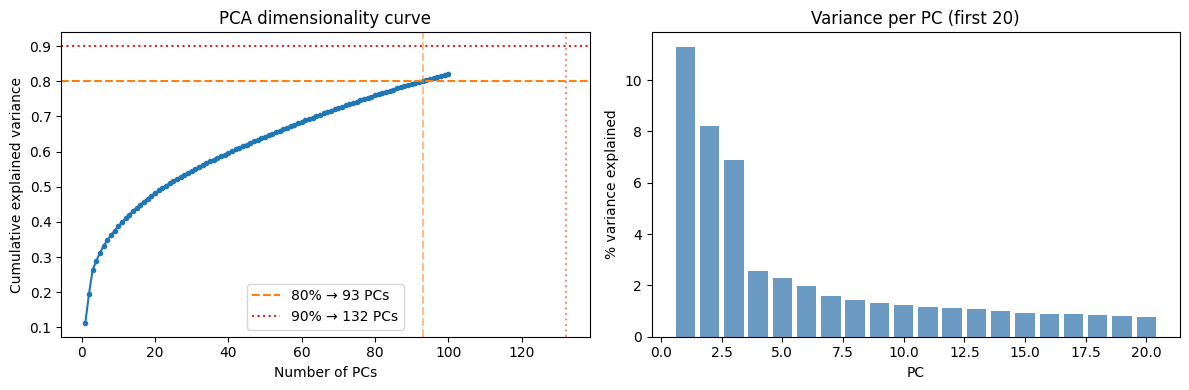

Using N_PCS = 20  (covers 48.2% of variance)
X_pca shape: (60000, 20)
PC score std before scaling: [4.962 4.227 3.879 2.354 2.242]
PC score std after  scaling: [1. 1. 1. 1. 1.]

Raw τ (from uncorrected PC scores):
  PC1  τ_raw  =  3366.4 bins = 67.33 s
  PC2  τ_raw  =  2250.5 bins = 45.01 s
  PC3  τ_raw  =  1627.6 bins = 32.55 s
  PC4  τ_raw  =   847.5 bins = 16.95 s
  PC5  τ_raw  =   447.3 bins = 8.95 s

Phase-detrended τ:
  PC1  τ_detrend =  1150.0 bins = 23.00 s
  PC2  τ_detrend =   603.5 bins = 12.07 s
  PC3  τ_detrend =   508.9 bins = 10.18 s
  PC4  τ_detrend =   816.0 bins = 16.32 s
  PC5  τ_detrend =   379.2 bins = 7.58 s

Using TAU_EFF = 1150.0 bins  (23.00 s)
→  n_eff = 52  (compression factor = 1150×)
   log(n_eff) = 3.955  [vs raw log(n) = 11.002]


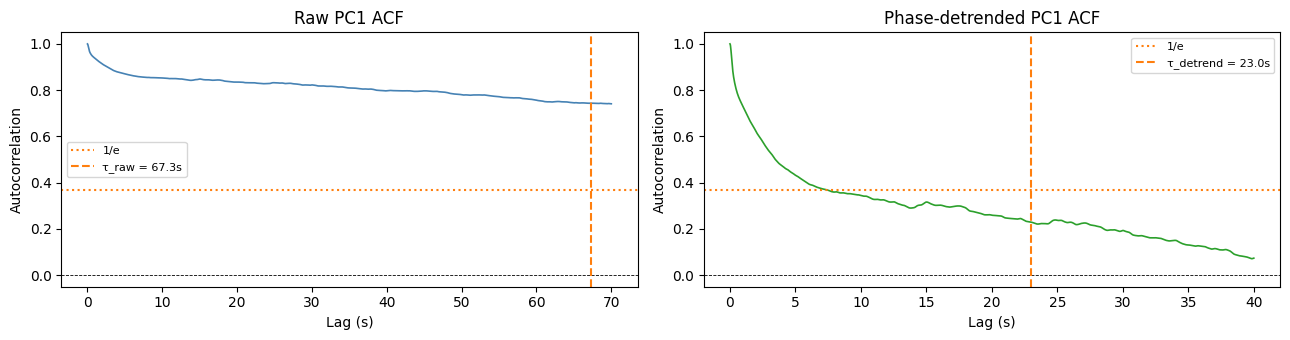

In [4]:
# =============================================================================
# REPRESENTATION FOR LATENT MODELLING
# =============================================================================
# Goal:
#   Build a compact, scaled neural representation for the HMM.
# Design choices:
#   1. PCA reduces dimensionality and parameter burden.
#   2. StandardScaler after PCA prevents PC1 from dominating the Gaussian emissions.
#   3. We keep N_PCS fixed at 20 for the main analysis and treat alternative values
#      as an appendix diagnostic rather than the core story.

X_full = FRz.T   # (n_timebins × n_neurons)

pca_full = PCA(random_state=0)
pca_full.fit(X_full)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_80 = int(np.searchsorted(cumvar, 0.80)) + 1
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f"PCs for 80% variance: {n_80}")
print(f"PCs for 90% variance: {n_90}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, min(len(cumvar) + 1, 101)), cumvar[:100], marker="o", ms=3)
axes[0].axhline(0.80, color="tab:orange", ls="--", label=f"80% → {n_80} PCs")
axes[0].axhline(0.90, color="tab:red",    ls=":",  label=f"90% → {n_90} PCs")
axes[0].axvline(n_80, color="tab:orange", ls="--", alpha=0.5)
axes[0].axvline(n_90, color="tab:red",    ls=":",  alpha=0.5)
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("PCA dimensionality curve")
axes[0].legend()

axes[1].bar(np.arange(1, 21),
            pca_full.explained_variance_ratio_[:20] * 100, color="steelblue", alpha=0.8)
axes[1].set_xlabel("PC")
axes[1].set_ylabel("% variance explained")
axes[1].set_title("Variance per PC (first 20)")
plt.tight_layout()
plt.show()

# Main analysis choice
N_PCS = 20

pca_hmm   = PCA(n_components=N_PCS, random_state=0)
X_pca_raw = pca_hmm.fit_transform(X_full)

scaler = StandardScaler()
X_pca  = scaler.fit_transform(X_pca_raw)

print(f"Using N_PCS = {N_PCS}  (covers {cumvar[N_PCS-1]*100:.1f}% of variance)")
print(f"X_pca shape: {X_pca.shape}")
print(f"PC score std before scaling: {X_pca_raw.std(axis=0)[:5].round(3)}")
print(f"PC score std after  scaling: {X_pca.std(axis=0)[:5].round(3)}")

# -----------------------------------------------------------------------------
# Phase-detrended autocorrelation time τ
# -----------------------------------------------------------------------------
# We use τ only as a diagnostic correction for information criteria.
# It is not the primary selector for K.
tau_raw_by_pc = {}
print("\nRaw τ (from uncorrected PC scores):")
for pc_i in range(5):
    t = compute_autocorr_time(X_pca[:, pc_i], max_lag=2000)
    tau_raw_by_pc[pc_i] = t
    print(f"  PC{pc_i+1}  τ_raw  = {t:7.1f} bins = {t/fs:.2f} s")

print()
tau_by_pc, X_pca_dt, acf_dt_pc0 = compute_phase_detrended_tau(
    X_pca, phase_masks, n_pcs=5, max_lag=2000)

print("Phase-detrended τ:")
for pc_i, t in tau_by_pc.items():
    print(f"  PC{pc_i+1}  τ_detrend = {t:7.1f} bins = {t/fs:.2f} s")

TAU_EFF = float(max(tau_by_pc.values()))
N_EFF   = len(X_pca) / TAU_EFF

print(f"\nUsing TAU_EFF = {TAU_EFF:.1f} bins  ({TAU_EFF/fs:.2f} s)")
print(f"→  n_eff = {N_EFF:.0f}  (compression factor = {len(X_pca)/N_EFF:.0f}×)")
print(f"   log(n_eff) = {np.log(N_EFF):.3f}  [vs raw log(n) = {np.log(len(X_pca)):.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

n_show = min(int(70 * fs) + 1, len(X_pca) - 1)
acf_raw = _acf_fft(X_pca[:, 0], n_show)
lag_s   = np.arange(len(acf_raw)) / fs
axes[0].plot(lag_s, acf_raw, color="steelblue", lw=1.2)
axes[0].axhline(0, color="k", lw=0.6, ls="--")
axes[0].axhline(1/np.e, color="tab:orange", ls=":", label="1/e")
axes[0].axvline(tau_raw_by_pc[0]/fs, color="tab:orange", ls="--",
                label=f"τ_raw = {tau_raw_by_pc[0]/fs:.1f}s")
axes[0].set_xlabel("Lag (s)")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Raw PC1 ACF")
axes[0].legend(fontsize=8)

lag_s_dt = np.arange(len(acf_dt_pc0)) / fs
axes[1].plot(lag_s_dt, acf_dt_pc0, color="tab:green", lw=1.2)
axes[1].axhline(0, color="k", lw=0.6, ls="--")
axes[1].axhline(1/np.e, color="tab:orange", ls=":", label="1/e")
axes[1].axvline(tau_by_pc[0]/fs, color="tab:orange", ls="--",
                label=f"τ_detrend = {tau_by_pc[0]/fs:.1f}s")
axes[1].set_xlabel("Lag (s)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("Phase-detrended PC1 ACF")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Fit candidate HMMs in a plausible range

This notebook now focuses on **K = 8..12**.  
The point here is not to let CV alone dictate the answer; it is to create a compact set of candidate models whose predictive fit and stability can then be judged against the structure checks in the next section.


Step 1 / 3 — fitting candidate HMMs …


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   38.6s remaining:   57.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Step 2 / 3 — temporal 5-fold CV …


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.7min remaining:  2.5min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  3.1min finished



Step 3 / 3 — state stability across seeds (ARI) …


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.5min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.6min finished



Candidate-model table:


,n_states,log_likelihood,n_params,BIC,BIC_corr,AIC,converged,cv_logL_per_bin,mean_ARI
0,8,-1427537.6524,383,2859289.1091,2856589.8997,2855841.3049,True,-28.2752,0.6764
1,9,-1409588.1322,440,2824017.1883,2820916.2688,2820056.2644,True,-28.1321,0.6092
2,10,-1396754.6719,499,2798999.3917,2795482.6672,2794507.3439,True,-27.6189,0.5968
3,11,-1401020.1765,560,2808201.5290,2804254.9042,2803160.3530,True,-27.9418,0.5203
4,12,-1367754.9474,623,2742364.2031,2737973.5831,2736755.8949,True,-27.4817,0.5511


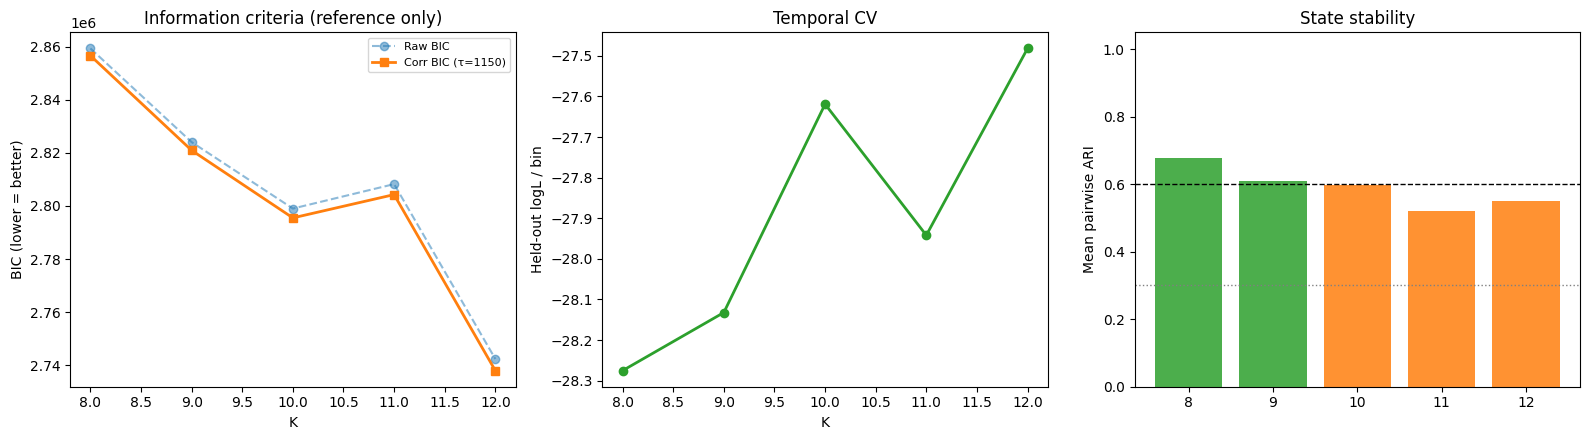

In [5]:
# =============================================================================
# CANDIDATE HMM FITS: K = 8..12
# =============================================================================
# We focus on K=8..12 because this is the range where earlier exploratory runs
# suggested the phase scaffold is not trivially collapsed, while larger K mostly
# risks over-splitting. Metrics here are supporting evidence only.
# Final selection is done in the next cell by structure preservation.

if not HMM_AVAILABLE:
    raise ImportError("hmmlearn is not installed.")

state_grid = [8, 9, 10, 11, 12]
N_JOBS = -1

def fit_one_k(K_sel):
    model, logL = fit_hmm_multistart(X_pca, n_states=K_sel,
                                     n_starts=3, n_iter=200)
    bic, aic, n_params = hmm_bic_aic(logL, K_sel, N_PCS, len(X_pca))
    bic_corr, _, _ = hmm_bic_aic_corrected(
        logL, K_sel, N_PCS, len(X_pca), TAU_EFF
    )
    return {
        "n_states": K_sel,
        "log_likelihood": float(logL),
        "n_params": int(n_params),
        "BIC": float(bic),
        "BIC_corr": float(bic_corr),
        "AIC": float(aic),
        "converged": bool(model.monitor_.converged),
        "model": model,
    }

print("Step 1 / 3 — fitting candidate HMMs …")
fit_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(fit_one_k)(K_sel) for K_sel in state_grid
)
fit_results = sorted(fit_results, key=lambda x: x["n_states"])
sel_models  = {r["n_states"]: r.pop("model") for r in fit_results}
model_sel_df = pd.DataFrame(fit_results)

print("\nStep 2 / 3 — temporal 5-fold CV …")
def cv_one_k(K_sel):
    cv_ll = hmm_cv_logL(X_pca, n_states=K_sel,
                        n_folds=5, n_starts=2, n_iter=150)
    return {"n_states": K_sel, "cv_logL_per_bin": float(cv_ll)}

cv_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(cv_one_k)(K_sel) for K_sel in state_grid
)
cv_df = pd.DataFrame(sorted(cv_results, key=lambda x: x["n_states"]))

print("\nStep 3 / 3 — state stability across seeds (ARI) …")
def ari_one_k(K_sel):
    ari = hmm_state_stability(X_pca, n_states=K_sel,
                              n_runs=6, n_iter=150)
    return {"n_states": K_sel, "mean_ARI": float(ari)}

ari_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(ari_one_k)(K_sel) for K_sel in state_grid
)
ari_df = pd.DataFrame(sorted(ari_results, key=lambda x: x["n_states"]))

ksel_df = (
    model_sel_df[["n_states", "log_likelihood", "n_params", "BIC", "BIC_corr", "AIC", "converged"]]
    .merge(cv_df, on="n_states")
    .merge(ari_df, on="n_states")
)

print("\nCandidate-model table:")
display(ksel_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
Ks = ksel_df["n_states"].values

axes[0].plot(Ks, ksel_df["BIC"], marker="o", ls="--", alpha=0.5, label="Raw BIC")
axes[0].plot(Ks, ksel_df["BIC_corr"], marker="s", lw=2, label=f"Corr BIC (τ={TAU_EFF:.0f})")
axes[0].set_xlabel("K")
axes[0].set_ylabel("BIC (lower = better)")
axes[0].set_title("Information criteria (reference only)")
axes[0].legend(fontsize=8)

axes[1].plot(Ks, ksel_df["cv_logL_per_bin"], marker="o", lw=2, color="tab:green")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Held-out logL / bin")
axes[1].set_title("Temporal CV")

ari_colors = [
    ("tab:green" if a >= 0.6 else "tab:orange" if a >= 0.3 else "tab:red")
    for a in ksel_df["mean_ARI"]
]
axes[2].bar(Ks.astype(str), ksel_df["mean_ARI"], color=ari_colors, alpha=0.85)
axes[2].axhline(0.6, color="k", ls="--", lw=1)
axes[2].axhline(0.3, color="gray", ls=":", lw=1)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Mean pairwise ARI")
axes[2].set_title("State stability")

plt.tight_layout()
plt.show()

## 5. Structure-first model selection

Primary criteria for a usable `K`:

1. each phase should have its own dominant state  
2. `WA` and `DA` should not collapse onto the same nearest state  
3. `attack`, `submission`, and `sniff` should not all map to the same dominant state  

Secondary diagnostic:

- the most attack-enriched state should not be **closer to non-attack than to attack**

If no `K` passes the attack-clean check, that is a result to report, not something to hide.


Focused structure comparison:


,K,converged,core_pass,phases_distinct,context_distinct,behaviours_distinct,attack_clean_pass,white_attack_clean,dark_attack_clean,attack_purer_than_nonattack,cv_logL_per_bin,mean_ARI,atk_state,atk_frac_in_state,dist_WA,dist_WN,dist_DA,dist_DN
0,8,True,False,True,True,False,False,False,False,False,-28.2752,0.6764,3,0.1299,3.1747,2.8682,7.0749,6.6523
1,9,True,False,True,True,False,False,False,False,False,-28.1321,0.6092,2,0.1300,3.1699,2.8438,7.0568,6.6346
2,10,True,False,True,True,False,False,False,False,False,-27.6189,0.5968,4,0.1252,5.0027,4.8908,3.5788,3.0620
3,11,True,True,True,True,True,False,False,False,False,-27.9418,0.5203,8,0.1274,3.2083,2.8850,7.0702,6.6440
4,12,True,False,True,True,False,False,False,False,False,-27.4817,0.5511,6,0.1368,5.4856,5.3750,3.9329,3.6970



------------------------------------------------------------------------
K=8 | core=FAIL | attack-clean=FAIL | ARI=0.676 | CV=-28.2752
  phase dominant: {'Pre': 0, 'WhiteAgg': 3, 'DarkAgg': 1, 'Post': 6}
  WA→state 3, DA→state 1
  behaviour dominant: {'attack': 3, 'submission': 3, 'sniff': 5}
  attack state = s3, attack fraction = 0.130
  Euclidean  WA=3.175, WN=2.868, DA=7.075, DN=6.652

------------------------------------------------------------------------
K=9 | core=FAIL | attack-clean=FAIL | ARI=0.609 | CV=-28.1321
  phase dominant: {'Pre': 0, 'WhiteAgg': 2, 'DarkAgg': 3, 'Post': 7}
  WA→state 2, DA→state 4
  behaviour dominant: {'attack': 2, 'submission': 2, 'sniff': 5}
  attack state = s2, attack fraction = 0.130
  Euclidean  WA=3.170, WN=2.844, DA=7.057, DN=6.635

------------------------------------------------------------------------
K=10 | core=FAIL | attack-clean=FAIL | ARI=0.597 | CV=-27.6189
  phase dominant: {'Pre': 0, 'WhiteAgg': 1, 'DarkAgg': 2, 'Post': 7}
  WA→state

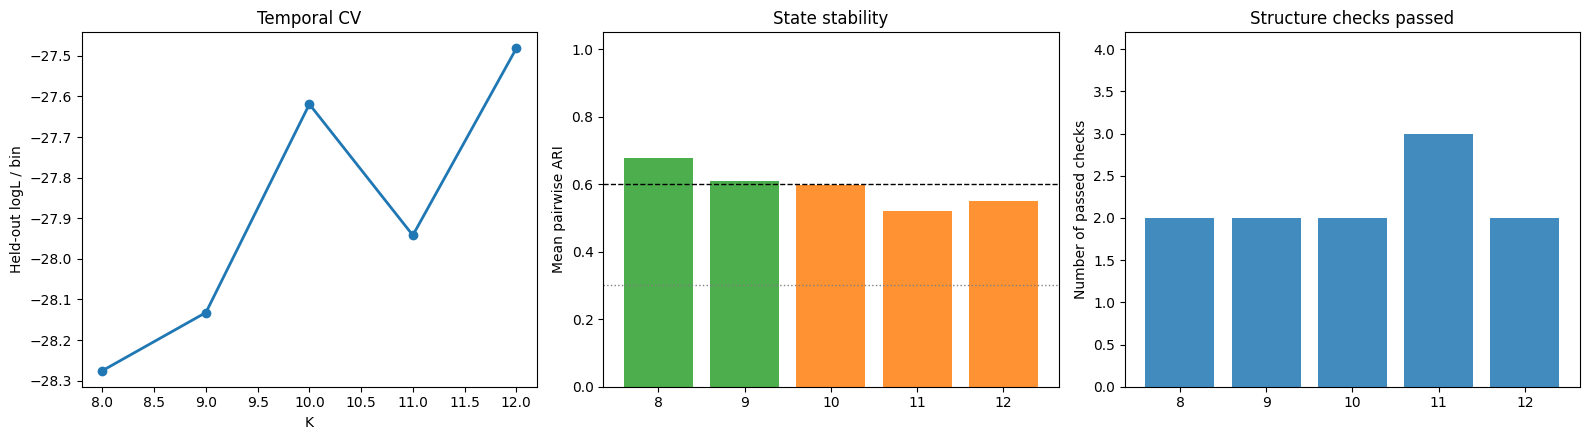


Selected final K = 11
Reason: smallest K passing the core structure checks
Final model — converged=True, train logL=-1401020.2


In [6]:
# =============================================================================
# STRUCTURE-FIRST K COMPARISON AND FINAL SELECTION
# =============================================================================
# Primary goal:
#   choose the smallest K that preserves the scientific structure we care about.
# Supporting evidence:
#   CV and ARI from the previous cell.
# Honest failure mode:
#   if no K yields an attack-clean state, report that explicitly.

from scipy.spatial.distance import cdist

K_COMPARE = list(state_grid)

def _condition_centroid(mask):
    return condition_pattern(FRz, np.asarray(mask).astype(bool))

def structure_check_local(K_sel, model):
    seq_raw = model.predict(X_pca)
    seq, state_order_local = reorder_states_by_occupancy(seq_raw, K_sel)

    state_cents = np.stack([_condition_centroid(seq == s) for s in range(K_sel)], axis=0)

    # Criterion 1: each phase has a distinct dominant state
    phase_dominant = {}
    for ph_name, ph_mask in phase_masks.items():
        bins = np.flatnonzero(np.asarray(ph_mask).astype(bool))
        if len(bins) == 0:
            continue
        counts = np.bincount(seq[bins], minlength=K_sel)
        phase_dominant[ph_name] = int(np.argmax(counts))
    phases_distinct = len(set(phase_dominant.values())) == len(phase_dominant)

    # Criterion 2: WA and DA map to different nearest states
    wa_mask = np.asarray(phase_masks["WhiteAgg"]).astype(bool) & np.asarray(attack).astype(bool)
    da_mask = np.asarray(phase_masks["DarkAgg"]).astype(bool)  & np.asarray(attack).astype(bool)
    wa_cent = _condition_centroid(wa_mask)
    da_cent = _condition_centroid(da_mask)
    wa_dists = np.linalg.norm(state_cents - wa_cent[None, :], axis=1)
    da_dists = np.linalg.norm(state_cents - da_cent[None, :], axis=1)
    wa_nearest = int(np.argmin(wa_dists))
    da_nearest = int(np.argmin(da_dists))
    context_distinct = (wa_nearest != da_nearest)

    # Criterion 3: attack / submission / sniff have different dominant states
    beh_masks_check = {
        "attack": np.asarray(attack).astype(bool),
        "submission": np.asarray(submission).astype(bool),
        "sniff": np.asarray(sniff_urine).astype(bool),
    }
    beh_dominant = {}
    for beh_name, beh_mask in beh_masks_check.items():
        bins = np.flatnonzero(beh_mask)
        if len(bins) == 0:
            continue
        counts = np.bincount(seq[bins], minlength=K_sel)
        beh_dominant[beh_name] = int(np.argmax(counts))
    behaviours_distinct = len(set(beh_dominant.values())) == len(beh_dominant)

    # Hard enrichment
    enrich_hard_local = behaviour_enrichment_hard(seq, behaviour_masks)
    frac_in_state_local = (enrich_hard_local
                           .pivot(index="state", columns="variable", values="fraction_in_state")
                           .fillna(0.0))
    atk_state = int(frac_in_state_local["attack"].idxmax())
    atk_frac  = float(frac_in_state_local.loc[atk_state, "attack"])

    # Optional "attack-clean" diagnostic in supervised attack / non-attack space
    sup_masks = {
        "WA": np.asarray(phase_masks["WhiteAgg"]).astype(bool) & np.asarray(attack).astype(bool),
        "WN": np.asarray(phase_masks["WhiteAgg"]).astype(bool) & (~np.asarray(attack).astype(bool)),
        "DA": np.asarray(phase_masks["DarkAgg"]).astype(bool)  & np.asarray(attack).astype(bool),
        "DN": np.asarray(phase_masks["DarkAgg"]).astype(bool)  & (~np.asarray(attack).astype(bool)),
    }
    sup_centroids = {nm: _condition_centroid(msk) for nm, msk in sup_masks.items()}
    atk_state_cent = state_cents[atk_state]

    d_eu = {nm: float(np.linalg.norm(atk_state_cent - sup_centroids[nm])) for nm in sup_masks}
    d_cos = {
        nm: float(1 - cdist(atk_state_cent[None, :], sup_centroids[nm][None, :], metric="cosine")[0, 0])
        for nm in sup_masks
    }

    white_attack_clean = d_eu["WA"] < d_eu["WN"]
    dark_attack_clean  = d_eu["DA"] < d_eu["DN"]
    mean_attack_dist   = 0.5 * (d_eu["WA"] + d_eu["DA"])
    mean_nonattack_dist = 0.5 * (d_eu["WN"] + d_eu["DN"])
    attack_purer_than_nonattack = mean_attack_dist < mean_nonattack_dist

    occ = (pd.Series(seq)
           .value_counts(normalize=True)
           .reindex(range(K_sel), fill_value=0.0)
           .sort_index())
    _, dwell_summary_local = state_dwell_summary(seq, fs=fs)

    core_pass = phases_distinct and context_distinct and behaviours_distinct
    attack_clean_pass = attack_purer_than_nonattack and dark_attack_clean

    return {
        "K": K_sel,
        "core_pass": core_pass,
        "phases_distinct": phases_distinct,
        "context_distinct": context_distinct,
        "behaviours_distinct": behaviours_distinct,
        "phase_dominant": phase_dominant,
        "wa_nearest": wa_nearest,
        "da_nearest": da_nearest,
        "beh_dominant": beh_dominant,
        "atk_state": atk_state,
        "atk_frac_in_state": atk_frac,
        "white_attack_clean": white_attack_clean,
        "dark_attack_clean": dark_attack_clean,
        "attack_purer_than_nonattack": attack_purer_than_nonattack,
        "attack_clean_pass": attack_clean_pass,
        "dist_WA": d_eu["WA"],
        "dist_WN": d_eu["WN"],
        "dist_DA": d_eu["DA"],
        "dist_DN": d_eu["DN"],
        "cos_WA": d_cos["WA"],
        "cos_WN": d_cos["WN"],
        "cos_DA": d_cos["DA"],
        "cos_DN": d_cos["DN"],
        "min_occ_frac": float(occ.min()),
        "mean_dwell_s": float(dwell_summary_local["mean"].mean()),
        "median_dwell_s": float(dwell_summary_local["median"].median()),
    }

compare_rows = []
for k in K_COMPARE:
    row = structure_check_local(k, sel_models[k])
    sub = ksel_df[ksel_df["n_states"] == k].iloc[0]
    row.update({
        "log_likelihood": float(sub["log_likelihood"]),
        "n_params": int(sub["n_params"]),
        "BIC": float(sub["BIC"]),
        "BIC_corr": float(sub["BIC_corr"]),
        "AIC": float(sub["AIC"]),
        "cv_logL_per_bin": float(sub["cv_logL_per_bin"]),
        "mean_ARI": float(sub["mean_ARI"]),
        "converged": bool(sub["converged"]),
    })
    compare_rows.append(row)

compare_df = pd.DataFrame(compare_rows).sort_values("K").reset_index(drop=True)

summary_cols = [
    "K",
    "converged",
    "core_pass",
    "phases_distinct",
    "context_distinct",
    "behaviours_distinct",
    "attack_clean_pass",
    "white_attack_clean",
    "dark_attack_clean",
    "attack_purer_than_nonattack",
    "cv_logL_per_bin",
    "mean_ARI",
    "atk_state",
    "atk_frac_in_state",
    "dist_WA", "dist_WN", "dist_DA", "dist_DN",
]
print("Focused structure comparison:")
display(compare_df[summary_cols].round(4))

for _, r in compare_df.iterrows():
    print("\n" + "-" * 72)
    print(f"K={int(r['K'])} | core={'PASS' if r['core_pass'] else 'FAIL'} | "
          f"attack-clean={'PASS' if r['attack_clean_pass'] else 'FAIL'} | "
          f"ARI={r['mean_ARI']:.3f} | CV={r['cv_logL_per_bin']:.4f}")
    print(f"  phase dominant: {r['phase_dominant']}")
    print(f"  WA→state {int(r['wa_nearest'])}, DA→state {int(r['da_nearest'])}")
    print(f"  behaviour dominant: {r['beh_dominant']}")
    print(f"  attack state = s{int(r['atk_state'])}, attack fraction = {r['atk_frac_in_state']:.3f}")
    print(f"  Euclidean  WA={r['dist_WA']:.3f}, WN={r['dist_WN']:.3f}, "
          f"DA={r['dist_DA']:.3f}, DN={r['dist_DN']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(compare_df["K"], compare_df["cv_logL_per_bin"], marker="o", lw=2)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Held-out logL / bin")
axes[0].set_title("Temporal CV")

ari_colors = [("tab:green" if a >= 0.6 else "tab:orange" if a >= 0.3 else "tab:red")
              for a in compare_df["mean_ARI"]]
axes[1].bar(compare_df["K"].astype(str), compare_df["mean_ARI"], color=ari_colors, alpha=0.85)
axes[1].axhline(0.6, color="k", ls="--", lw=1)
axes[1].axhline(0.3, color="gray", ls=":", lw=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Mean pairwise ARI")
axes[1].set_title("State stability")

pass_count = (
    compare_df["phases_distinct"].astype(int)
    + compare_df["context_distinct"].astype(int)
    + compare_df["behaviours_distinct"].astype(int)
    + compare_df["attack_clean_pass"].astype(int)
)
axes[2].bar(compare_df["K"].astype(str), pass_count, alpha=0.85)
axes[2].set_ylabel("Number of passed checks")
axes[2].set_ylim(0, 4.2)
axes[2].set_title("Structure checks passed")

plt.tight_layout()
plt.show()

core_ok = compare_df[compare_df["core_pass"]].copy()
strong_ok = core_ok[core_ok["attack_clean_pass"]].copy()

if len(strong_ok) > 0:
    strong_ok = strong_ok.sort_values(by=["K", "mean_ARI", "cv_logL_per_bin"],
                                      ascending=[True, False, False])
    K_best_science = int(strong_ok.iloc[0]["K"])
    selection_reason = "smallest K passing both core-structure and attack-clean checks"
elif len(core_ok) > 0:
    core_ok = core_ok.sort_values(by=["K", "mean_ARI", "cv_logL_per_bin"],
                                  ascending=[True, False, False])
    K_best_science = int(core_ok.iloc[0]["K"])
    selection_reason = "smallest K passing the core structure checks"
else:
    tmp = compare_df.copy()
    tmp["n_pass"] = pass_count.values
    tmp = tmp.sort_values(by=["n_pass", "mean_ARI", "cv_logL_per_bin", "K"],
                          ascending=[False, False, False, True])
    K_best_science = int(tmp.iloc[0]["K"])
    selection_reason = "fallback: highest number of passed checks"

K = K_best_science
hmm_final = sel_models[K]

print("\n" + "=" * 80)
print(f"Selected final K = {K}")
print(f"Reason: {selection_reason}")
print("=" * 80)
print(f"Final model — converged={hmm_final.monitor_.converged}, train logL={hmm_final.score(X_pca):.1f}")

## 6. Decode the selected model and inspect the latent scaffold

After choosing the final `K`, the first thing to look at is the **session-level scaffold**:

- hard Viterbi state sequence
- state raster
- soft posterior stackplot

This tells me whether the model has recovered a coherent phase-aligned structure before I read too much into any behaviour-specific interpretation.


State occupancy (0 = most occupied):
{0: 0.154, 1: 0.148, 2: 0.13, 3: 0.099, 4: 0.095, 5: 0.087, 6: 0.081, 7: 0.063, 8: 0.063, 9: 0.049, 10: 0.031}

State remapping (original → sorted): {np.int64(9): 0, np.int64(6): 1, np.int64(0): 2, np.int64(4): 3, np.int64(1): 4, np.int64(8): 5, np.int64(10): 6, np.int64(3): 7, np.int64(2): 8, np.int64(7): 9, np.int64(5): 10}


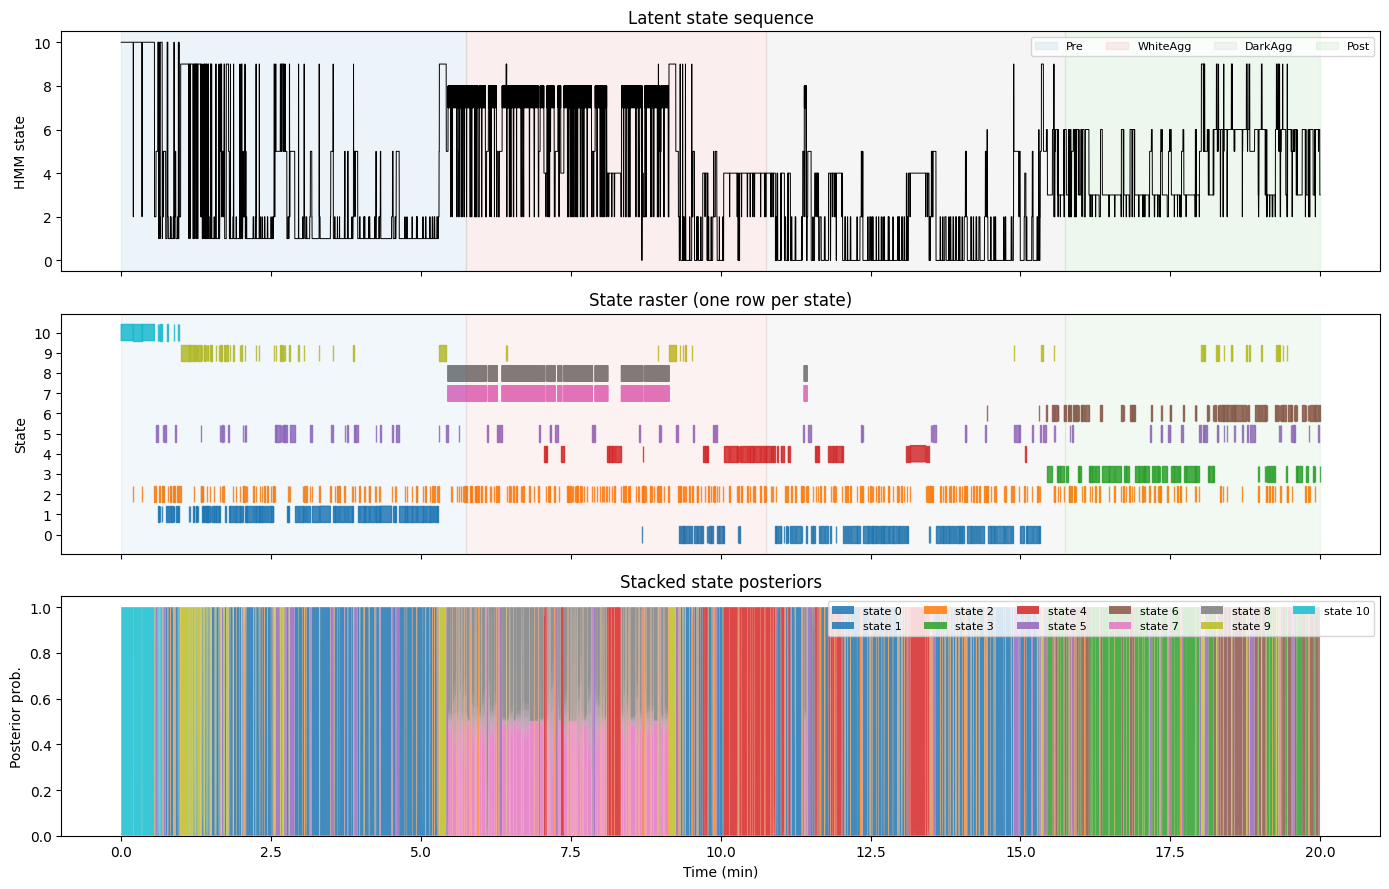

In [7]:
# =============================================================================
# FINAL MODEL DECODE + SESSION OVERVIEW
# =============================================================================

state_seq_raw  = hmm_final.predict(X_pca)
state_post_raw = hmm_final.predict_proba(X_pca)

state_seq, state_order = reorder_states_by_occupancy(state_seq_raw, K)
state_post = state_post_raw[:, [k for k, _ in sorted(state_order.items(), key=lambda x: x[1])]]

occupancy = pd.Series(state_seq).value_counts(normalize=True).sort_index()
print(f"State occupancy (0 = most occupied):\n{occupancy.round(3).to_dict()}")
print(f"\nState remapping (original → sorted): {state_order}")

cmap_states = matplotlib.colormaps.get_cmap("tab10")
phase_colors = {"Pre": "tab:blue", "WhiteAgg": "tab:red",
                "DarkAgg": "gray",   "Post": "tab:green"}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t_min, state_seq, lw=0.7, color="black")
for phase_name, pm in phase_masks.items():
    idx = np.flatnonzero(pm)
    if len(idx):
        axes[0].axvspan(idx[0]/fs/60, idx[-1]/fs/60,
                        alpha=0.08, color=phase_colors[phase_name], label=phase_name)
axes[0].set_ylabel("HMM state")
axes[0].set_title("Latent state sequence")
axes[0].legend(loc="upper right", ncol=4, fontsize=8)

for s in range(K):
    mask_s = state_seq == s
    axes[1].fill_between(t_min, s - 0.4, s + 0.4,
                         where=mask_s, color=cmap_states(s / max(K, 1)), alpha=0.85)
for phase_name, pm in phase_masks.items():
    idx = np.flatnonzero(pm)
    if len(idx):
        axes[1].axvspan(idx[0]/fs/60, idx[-1]/fs/60,
                        alpha=0.06, color=phase_colors[phase_name])
axes[1].set_ylabel("State")
axes[1].set_yticks(range(K))
axes[1].set_title("State raster (one row per state)")

axes[2].stackplot(t_min, state_post.T,
                  colors=[cmap_states(s / max(K, 1)) for s in range(K)],
                  labels=[f"state {s}" for s in range(K)], alpha=0.85)
axes[2].set_ylabel("Posterior prob.")
axes[2].set_xlabel("Time (min)")
axes[2].set_title("Stacked state posteriors")
axes[2].legend(loc="upper right", ncol=min(K, 6), fontsize=8)

plt.tight_layout()
plt.show()

## 7. Behaviour alignment and phase occupancy

This section answers two separate questions:

- **Behaviour alignment:** which behaviours are enriched inside each state?
- **Phase occupancy:** how is the latent scaffold distributed across Pre / WhiteAgg / DarkAgg / Post?

The bootstrap test is used only to quantify the Pre → Post occupancy change more cleanly.


Hard alignment — P(behaviour | state):


variable,attack,chase,lick_empty,lick_milk,sniff_urine,submission,white_light
state,,,,,,,
0,0.0860,0.0010,0.0000,0.0000,0.0000,0.0780,0.1510
1,0.0000,0.0000,0.0030,0.0160,0.0370,0.0000,0.1580
2,0.1020,0.0060,0.0020,0.0020,0.0590,0.1370,0.3570
3,0.0440,0.0000,0.0000,0.0000,0.0270,0.0000,0.0000
4,0.1120,0.0030,0.0000,0.0000,0.0000,0.2080,0.5460
5,0.0210,0.0000,0.0260,0.0000,0.0940,0.0410,0.2180
6,0.0570,0.0000,0.0140,0.0000,0.0640,0.0000,0.0000
7,0.1260,0.0080,0.0000,0.0000,0.0000,0.3010,0.9880
8,0.1270,0.0070,0.0000,0.0000,0.0000,0.3010,0.9880



Hard alignment — P(state | behaviour):


variable,attack,chase,lick_empty,lick_milk,sniff_urine,submission,white_light
state,,,,,,,
0,0.2060,0.0520,0.0000,0.0000,0.0000,0.1290,0.0770
1,0.0000,0.0000,0.0470,0.1390,0.1850,0.0000,0.0780
2,0.2070,0.3580,0.0210,0.0160,0.2570,0.1920,0.1540
3,0.0680,0.0000,0.0000,0.0000,0.0910,0.0000,0.0000
4,0.1650,0.1190,0.0000,0.0000,0.0000,0.2120,0.1720
5,0.0290,0.0000,0.2380,0.0010,0.2790,0.0380,0.0630
6,0.0720,0.0000,0.1190,0.0000,0.1760,0.0000,0.0000
7,0.1230,0.2160,0.0000,0.0000,0.0000,0.2040,0.2070
8,0.1250,0.2010,0.0000,0.0000,0.0000,0.2040,0.2070



Soft alignment — mean posterior P(state | behaviour):


variable,attack,chase,lick_empty,lick_milk,sniff_urine,submission,white_light
state,,,,,,,
0,0.2050,0.0520,0.0000,0.0000,0.0000,0.1290,0.0770
1,0.0000,0.0000,0.0470,0.1440,0.1830,0.0000,0.0780
2,0.2070,0.3530,0.0240,0.0150,0.2580,0.1910,0.1530
3,0.0680,0.0000,0.0000,0.0000,0.0910,0.0000,0.0000
4,0.1650,0.1190,0.0000,0.0000,0.0000,0.2130,0.1720
5,0.0290,0.0000,0.2390,0.0010,0.2780,0.0380,0.0630
6,0.0720,0.0000,0.1160,0.0000,0.1770,0.0000,0.0000
7,0.1240,0.2150,0.0000,0.0000,0.0000,0.2050,0.2070
8,0.1250,0.2100,0.0000,0.0000,0.0000,0.2050,0.2070


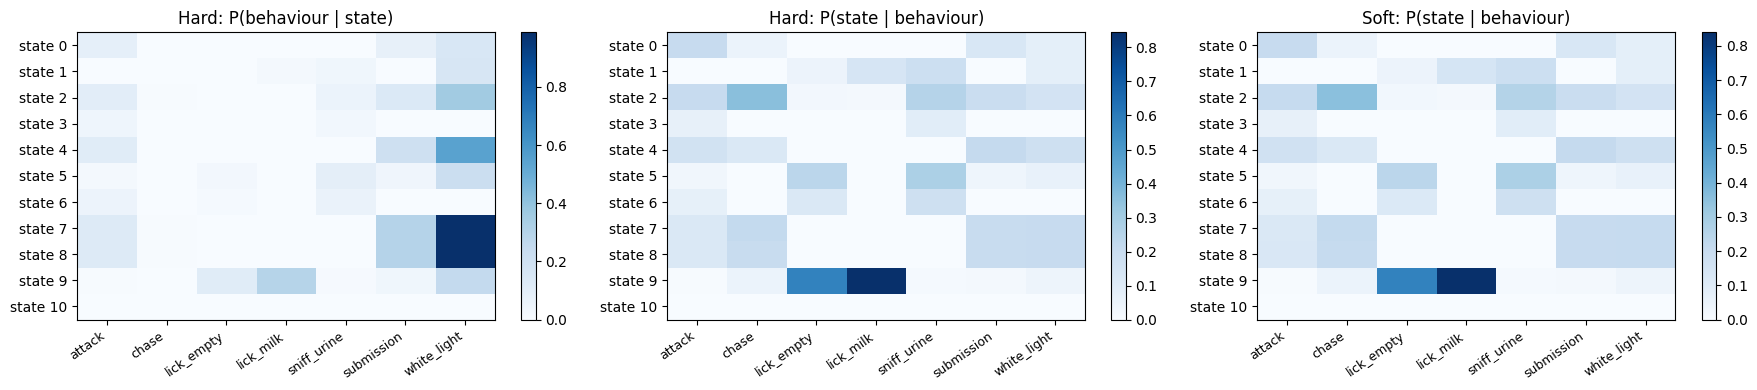

Phase × state occupancy:


state,0,1,2,3,4,5,6,7,8,9,10
phase,,,,,,,,,,,
DarkAgg,0.5230,0.0000,0.1560,0.0360,0.1730,0.0760,0.0210,0.0030,0.0030,0.0080,0.0000
Post,0.0000,0.0000,0.0910,0.4240,0.0000,0.0920,0.3570,0.0000,0.0000,0.0370,0.0000
Pre,0.0000,0.5160,0.1100,0.0000,0.0000,0.1100,0.0000,0.0210,0.0210,0.1140,0.1080
WhiteAgg,0.0930,0.0000,0.1580,0.0000,0.2050,0.0680,0.0000,0.2240,0.2240,0.0270,0.0000



Bootstrap 95% CI for (Post − Pre) occupancy difference (n_boot=1000):


,state,obs_diff,ci_lo,ci_hi,significant
0,0,0.0000,0.0000,0.0000,False
1,1,-0.5157,-0.5233,-0.5079,True
2,2,-0.0196,-0.0265,-0.0130,True
3,3,0.4238,0.4154,0.4328,True
4,4,0.0000,0.0000,0.0000,False
5,5,-0.0176,-0.0244,-0.0107,True
6,6,0.3567,0.3478,0.3654,True
7,7,-0.0212,-0.0235,-0.0191,True
8,8,-0.0212,-0.0234,-0.0191,True
9,9,-0.0772,-0.0836,-0.0714,True


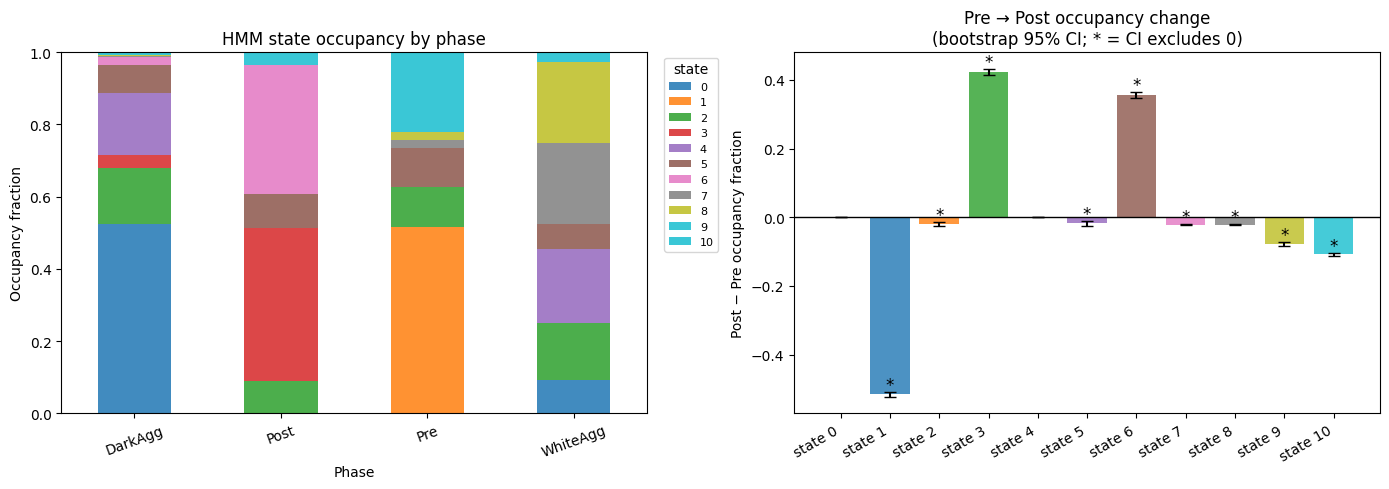

In [8]:
# =============================================================================
# BEHAVIOUR ALIGNMENT + PHASE OCCUPANCY
# =============================================================================

enrich_hard   = behaviour_enrichment_hard(state_seq, behaviour_masks)
frac_in_state = enrich_hard.pivot(index="state", columns="variable",
                                  values="fraction_in_state")
frac_of_var   = enrich_hard.pivot(index="state", columns="variable",
                                  values="fraction_of_var")

print("Hard alignment — P(behaviour | state):")
display(frac_in_state.round(3))
print("\nHard alignment — P(state | behaviour):")
display(frac_of_var.round(3))

enrich_soft = behaviour_enrichment_soft(state_post, behaviour_masks)
soft_pivot  = enrich_soft.pivot(index="state", columns="variable",
                                values="mean_posterior_given_behaviour")
print("\nSoft alignment — mean posterior P(state | behaviour):")
display(soft_pivot.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, data, title in [
    (axes[0], frac_in_state, "Hard: P(behaviour | state)"),
    (axes[1], frac_of_var,   "Hard: P(state | behaviour)"),
    (axes[2], soft_pivot,    "Soft: P(state | behaviour)"),
]:
    if data is not None and len(data):
        vals = data.values.astype(float)
        im = ax.imshow(vals, aspect="auto", cmap="Blues",
                       vmin=0, vmax=max(vals.max(), 1e-6))
        ax.set_xticks(range(len(data.columns)))
        ax.set_xticklabels(data.columns, rotation=35, ha="right", fontsize=9)
        ax.set_yticks(range(len(data.index)))
        ax.set_yticklabels([f"state {s}" for s in data.index])
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

occ_phase_df = state_occupancy_by_phase(state_seq, phase_masks)
phase_occ_table = (occ_phase_df
                   .pivot(index="phase", columns="state",
                          values="occupancy_fraction")
                   .fillna(0.0))
print("Phase × state occupancy:")
display(phase_occ_table.round(3))

print("\nBootstrap 95% CI for (Post − Pre) occupancy difference (n_boot=1000):")
prepost_df = bootstrap_prepost_diff(state_seq, phase_masks, K,
                                    n_boot=1000, seed=42)
display(prepost_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

phase_occ_table.plot(kind="bar", stacked=True, ax=axes[0],
                     colormap="tab10", alpha=0.85)
axes[0].set_ylabel("Occupancy fraction")
axes[0].set_xlabel("Phase")
axes[0].set_title("HMM state occupancy by phase")
axes[0].legend(title="state", bbox_to_anchor=(1.02, 1),
               loc="upper left", fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

for s in range(K):
    row = prepost_df[prepost_df["state"] == s].iloc[0]
    col = cmap_states(s / max(K, 1))
    axes[1].bar(s, row["obs_diff"], color=col, alpha=0.8)
    axes[1].errorbar(
        s, row["obs_diff"],
        yerr=[[row["obs_diff"] - row["ci_lo"]],
              [row["ci_hi"]   - row["obs_diff"]]],
        fmt="none", color="black", capsize=4
    )
    if row["significant"]:
        axes[1].text(s, row["ci_hi"] + 0.005, "*", ha="center", fontsize=12)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xticks(range(K))
axes[1].set_xticklabels([f"state {s}" for s in range(K)], rotation=30, ha="right")
axes[1].set_ylabel("Post − Pre occupancy fraction")
axes[1].set_title("Pre → Post occupancy change\n(bootstrap 95% CI; * = CI excludes 0)")
plt.tight_layout()
plt.show()

## 8. Transition structure, dwell times, and event-locked dynamics

Now that the scaffold is visible, I can ask whether it is dynamically meaningful:

- are the transitions structured?
- do states persist for sensible timescales?
- do attack onsets modulate state occupancy in a phase-dependent way?


Transition matrix:


,state_0,state_1,state_2,state_3,state_4,state_5,state_6,state_7,state_8,state_9,state_10
state_0,0.9890,0.0000,0.0090,0.0000,0.0020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
state_1,0.0000,0.9890,0.0070,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0030,0.0010
state_2,0.0090,0.0060,0.9540,0.0030,0.0040,0.0090,0.0030,0.0090,0.0000,0.0020,0.0000
state_3,0.0000,0.0000,0.0050,0.9910,0.0000,0.0000,0.0030,0.0000,0.0000,0.0000,0.0000
state_4,0.0030,0.0000,0.0050,0.0000,0.9910,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
state_5,0.0010,0.0030,0.0050,0.0000,0.0000,0.9800,0.0060,0.0020,0.0000,0.0030,0.0000
state_6,0.0000,0.0000,0.0060,0.0060,0.0000,0.0020,0.9830,0.0000,0.0000,0.0030,0.0000
state_7,0.0000,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000,0.0000,0.9990,0.0000,0.0000
state_8,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.9760,0.0030,0.0010,0.0000
state_9,0.0000,0.0100,0.0060,0.0000,0.0000,0.0080,0.0020,0.0000,0.0000,0.9740,0.0000



Dwell-time summary (s):


,state,count,mean,median,std,sum
0,0,95,1.9450,1.7600,1.5350,184.7400
1,1,95,1.8730,1.2800,2.0110,177.9000
2,2,346,0.4490,0.3600,0.3040,155.5200
3,3,51,2.3280,2.0800,1.9030,118.7400
4,4,47,2.4170,1.5600,2.6030,113.6200
5,5,98,1.0690,0.5800,1.1170,104.8000
6,6,78,1.2480,0.7700,1.3070,97.3400
7,7,3779,0.0200,0.0200,0.0000,75.5800
8,8,3776,0.0200,0.0200,0.0000,75.5200
9,9,74,0.7970,0.2800,1.4620,58.9800


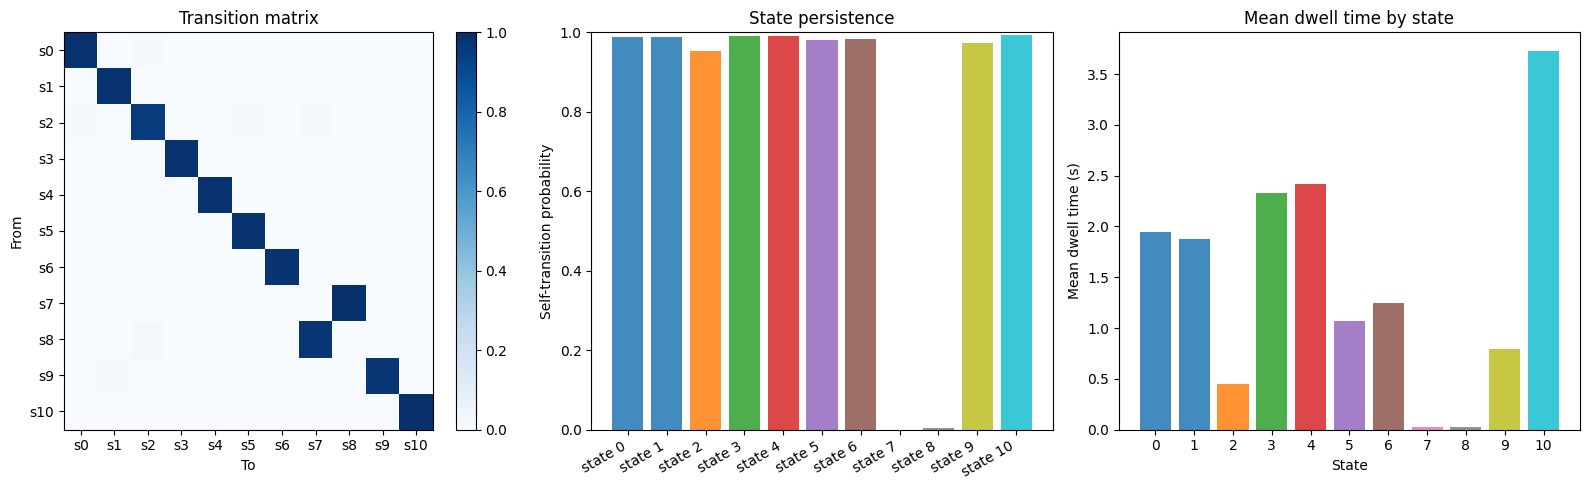


Attack onsets — White: 38,  Dark: 33


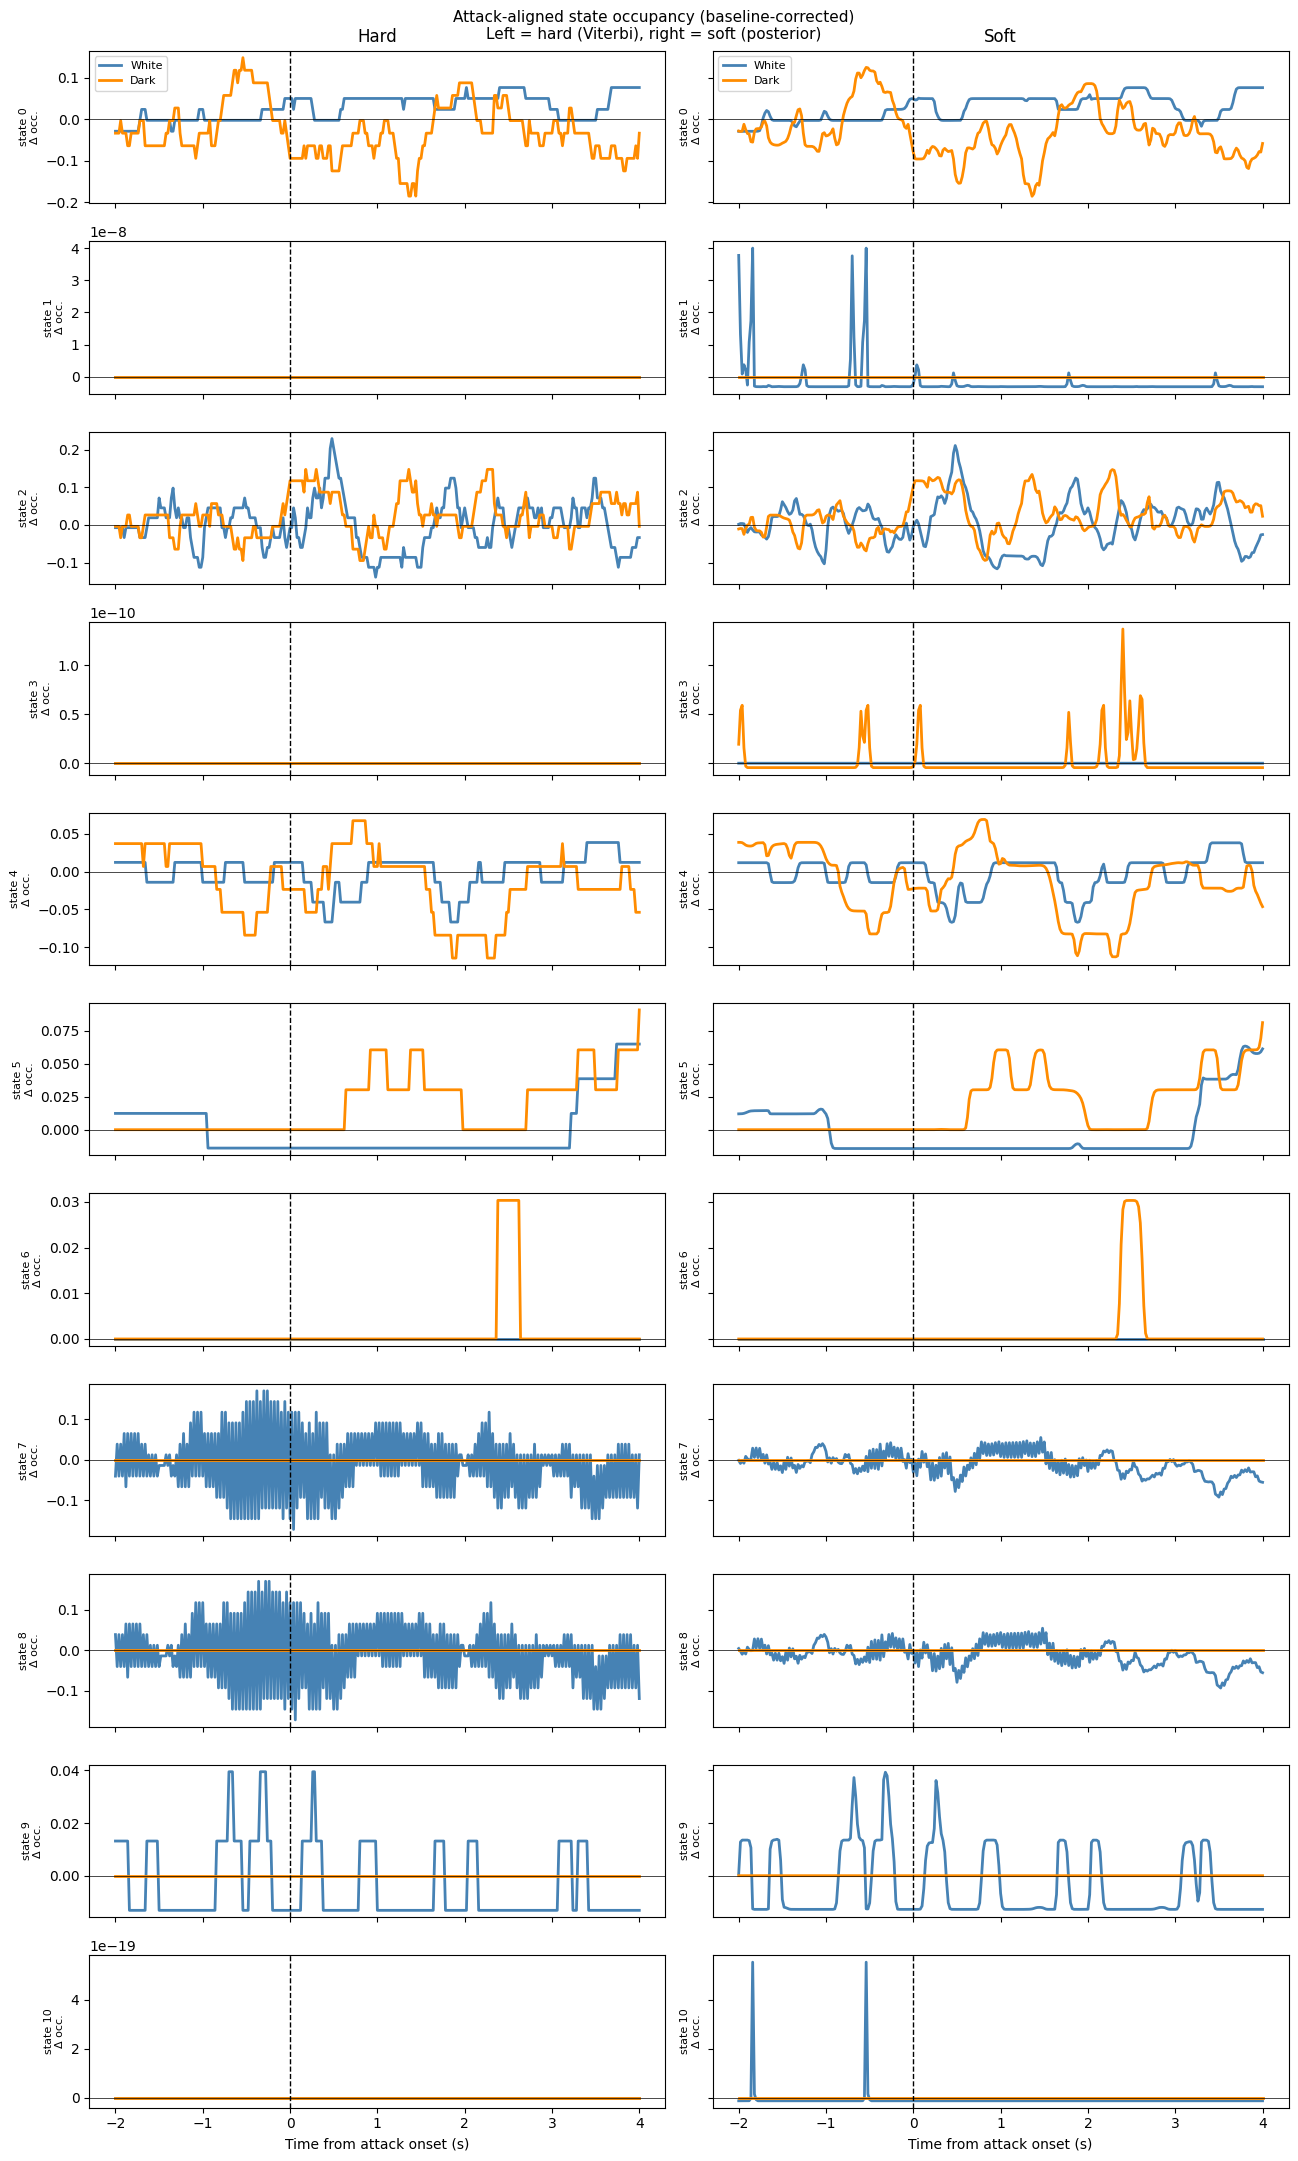

In [9]:
# =============================================================================
# TRANSITION STRUCTURE, DWELL TIMES, AND ATTACK-ALIGNED DYNAMICS
# =============================================================================

new_order_keys = [k for k, _ in sorted(state_order.items(), key=lambda x: x[1])]
transmat_df = pd.DataFrame(
    hmm_final.transmat_[np.ix_(new_order_keys, new_order_keys)],
    index=[f"state_{i}" for i in range(K)],
    columns=[f"state_{i}" for i in range(K)],
)
print("Transition matrix:")
display(transmat_df.round(3))

dwell_df, dwell_summary = state_dwell_summary(state_seq, fs=fs)
print("\nDwell-time summary (s):")
display(dwell_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im = axes[0].imshow(transmat_df.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(K))
axes[0].set_xticklabels([f"s{i}" for i in range(K)])
axes[0].set_yticks(range(K))
axes[0].set_yticklabels([f"s{i}" for i in range(K)])
axes[0].set_xlabel("To")
axes[0].set_ylabel("From")
axes[0].set_title("Transition matrix")
plt.colorbar(im, ax=axes[0])

self_trans = np.diag(transmat_df.values)
axes[1].bar(range(K), self_trans,
            color=[cmap_states(s / max(K, 1)) for s in range(K)], alpha=0.85)
axes[1].set_xticks(range(K))
axes[1].set_xticklabels([f"state {s}" for s in range(K)], rotation=30, ha="right")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Self-transition probability")
axes[1].set_title("State persistence")

axes[2].bar(dwell_summary["state"].astype(str), dwell_summary["mean"],
            color=[cmap_states(s / max(K, 1)) for s in dwell_summary["state"]], alpha=0.85)
axes[2].set_xlabel("State")
axes[2].set_ylabel("Mean dwell time (s)")
axes[2].set_title("Mean dwell time by state")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Attack-aligned latent-state occupancy (PETH)
# -----------------------------------------------------------------------------
pre_sec   = 2.0
post_sec  = 4.0
pre_bins  = int(pre_sec * fs)
post_bins = int(post_sec * fs)
nT        = len(state_seq)
time_event = np.arange(-pre_bins, post_bins + 1) / fs

all_onsets = np.flatnonzero(
    np.diff(np.concatenate([[False], attack]).astype(int)) == 1
)

def filter_onsets(onsets, phase_mask, nT, pre_b, post_b):
    return np.array([o for o in onsets.astype(int)
                     if pre_b <= o < nT - post_b and phase_mask[o]], dtype=int)

white_onsets = filter_onsets(all_onsets, phase_masks["WhiteAgg"], nT, pre_bins, post_bins)
dark_onsets  = filter_onsets(all_onsets, phase_masks["DarkAgg"],  nT, pre_bins, post_bins)
print(f"\nAttack onsets — White: {len(white_onsets)},  Dark: {len(dark_onsets)}")

hard_peth_w, soft_peth_w = attack_state_peth(
    state_seq, state_post, K, white_onsets, pre_bins, post_bins
)
hard_peth_d, soft_peth_d = attack_state_peth(
    state_seq, state_post, K, dark_onsets, pre_bins, post_bins
)

fig, axes = plt.subplots(K, 2, figsize=(13, max(2.0 * K, 6)), sharex=True, sharey="row")
if K == 1:
    axes = np.array([axes])
fig.suptitle("Attack-aligned state occupancy (baseline-corrected)\n"
             "Left = hard (Viterbi), right = soft (posterior)", fontsize=11)
for s in range(K):
    for col, peth_w, peth_d, label in [
        (0, hard_peth_w, hard_peth_d, "Hard"),
        (1, soft_peth_w, soft_peth_d, "Soft"),
    ]:
        ax = axes[s, col]
        ax.plot(time_event, peth_w[s], lw=2, label="White", color="steelblue")
        ax.plot(time_event, peth_d[s], lw=2, label="Dark",  color="darkorange")
        ax.axvline(0, color="k", lw=1, ls="--")
        ax.axhline(0, color="k", lw=0.5)
        ax.set_ylabel(f"state {s}\nΔ occ.", fontsize=8)
        if s == 0:
            ax.set_title(label)
            ax.legend(fontsize=8)
axes[-1, 0].set_xlabel("Time from attack onset (s)")
axes[-1, 1].set_xlabel("Time from attack onset (s)")
plt.tight_layout()
plt.show()

## 9. Bridge back to the supervised notebook

This section is not for discovering a new story.  
It is for checking whether the **label-free latent states** land in roughly the same part of neural space as the supervised conditions from the earlier notebook.


Shared PCA explained variance (PC1-3): [0.1129 0.082  0.069 ]


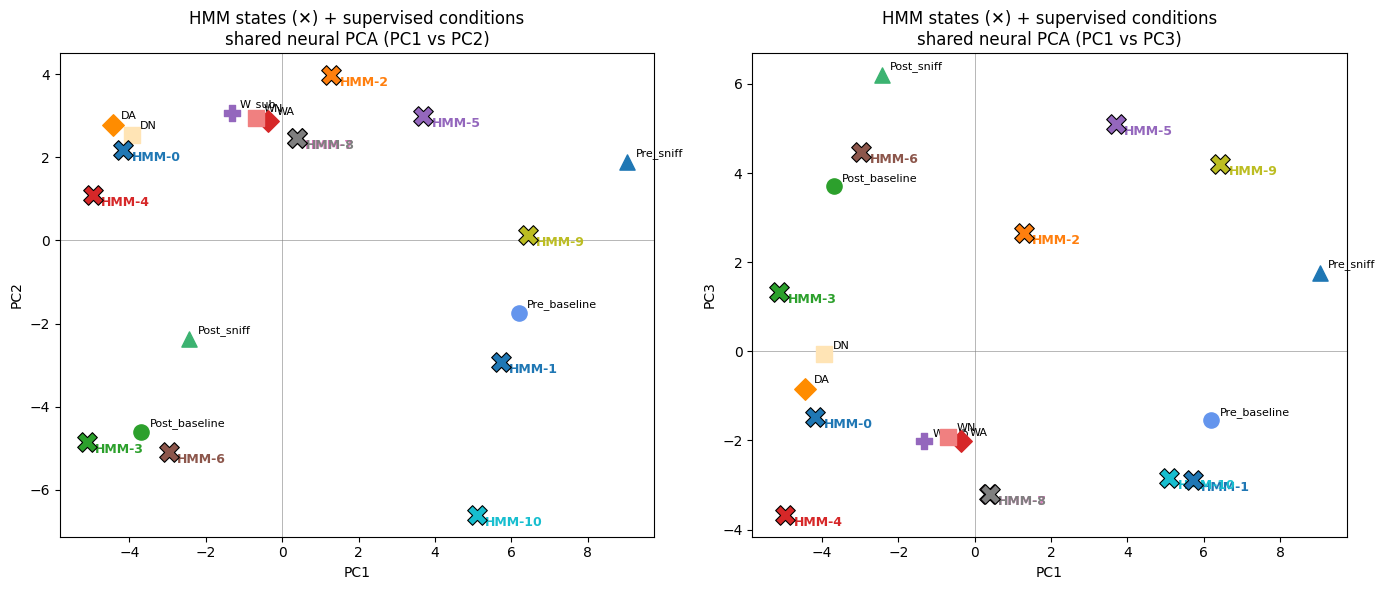


Nearest HMM state to each supervised condition (PC1-2 Euclidean):


,HMM-0,HMM-1,HMM-2,HMM-3,HMM-4,HMM-5,HMM-6,HMM-7,HMM-8,HMM-9,HMM-10,nearest_HMM_state
Pre_baseline,11.0810,1.2760,7.5390,11.7260,11.5060,5.3530,9.7480,7.1710,7.1690,1.8970,4.9720,HMM-1
Pre_sniff,13.2020,5.8490,8.0250,15.6690,14.0120,5.4540,13.8780,8.6660,8.6620,3.1410,9.3540,HMM-9
WA,3.8670,8.4020,1.9790,9.0670,4.9300,4.0520,8.3760,0.8530,0.8550,7.3180,10.9250,HMM-7
WN,3.5580,8.6990,2.2230,8.9680,4.6550,4.3810,8.3570,1.1850,1.1870,7.6550,11.1630,HMM-7
W_sub,2.9730,9.2500,2.7630,8.7750,4.1350,5.0160,8.3180,1.8170,1.8190,8.2880,11.5990,HMM-7
DA,0.6580,11.6520,5.8450,7.6610,1.7730,8.1310,8.0090,4.8350,4.8390,11.1840,13.3710,HMM-0
DN,0.4260,11.1010,5.4160,7.4860,1.7770,7.6430,7.6970,4.3260,4.3310,10.6430,12.8500,HMM-0
Post_sniff,4.8690,8.1660,7.3460,3.6570,4.2780,8.1270,2.7770,5.5830,5.5880,9.2020,8.6300,HMM-6
Post_baseline,6.8100,9.5480,9.9150,1.4520,5.8360,10.5830,0.8650,8.1520,8.1580,11.1670,8.9970,HMM-6


In [10]:
# =============================================================================
# SECTION 11 · Overlay: HMM states + supervised conditions in shared PCA space
# =============================================================================

supervised_masks = {
    "Pre_baseline":  phase_masks["Pre"]  & (~sniff_urine) & (~lick_milk) & (~lick_empty),
    "Pre_sniff":     phase_masks["Pre"]  & sniff_urine,
    "WA":            phase_masks["WhiteAgg"] & attack,
    "WN":            phase_masks["WhiteAgg"] & (~attack),
    "W_sub":         phase_masks["WhiteAgg"] & submission,
    "DA":            phase_masks["DarkAgg"]  & attack,
    "DN":            phase_masks["DarkAgg"]  & (~attack),
    "Post_sniff":    phase_masks["Post"] & sniff_urine,
    "Post_baseline": phase_masks["Post"] & (~sniff_urine) & (~lick_milk) & (~lick_empty),
}
valid_sup = {k: v for k, v in supervised_masks.items()
             if int(np.asarray(v).astype(bool).sum()) > 10}

pca_shared = PCA(n_components=3, random_state=0)
pca_shared.fit(X_full)

X_sup  = np.stack([condition_pattern(FRz, v) for v in valid_sup.values()], axis=0)
Z_sup  = pca_shared.transform(X_sup)

state_cent_neural = np.stack(
    [FRz[:, state_seq == s].mean(axis=1) for s in range(K)], axis=0)
Z_hmm = pca_shared.transform(state_cent_neural)

print("Shared PCA explained variance (PC1-3):",
      np.round(pca_shared.explained_variance_ratio_, 4))

sup_markers = {"Pre_baseline": "o", "Pre_sniff": "^",
               "WA": "D", "WN": "s", "W_sub": "P",
               "DA": "D", "DN": "s",
               "Post_sniff": "^", "Post_baseline": "o"}
sup_colors  = {"Pre_baseline": "cornflowerblue", "Pre_sniff": "tab:blue",
               "WA": "tab:red",       "WN": "lightcoral",
               "W_sub": "tab:purple",
               "DA": "darkorange",    "DN": "moccasin",
               "Post_sniff": "mediumseagreen", "Post_baseline": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_idx, (pc_x, pc_y) in enumerate([(0, 1), (0, 2)]):
    ax = axes[ax_idx]
    for i, nm in enumerate(valid_sup.keys()):
        ax.scatter(Z_sup[i, pc_x], Z_sup[i, pc_y],
                   s=120, color=sup_colors.get(nm, "gray"),
                   marker=sup_markers.get(nm, "o"), zorder=5, label=nm)
        ax.annotate(nm, (Z_sup[i, pc_x], Z_sup[i, pc_y]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    for s in range(K):
        ax.scatter(Z_hmm[s, pc_x], Z_hmm[s, pc_y],
                   s=200, color=cmap_states(s / K), marker="X",
                   edgecolors="black", linewidths=0.8, zorder=6)
        ax.annotate(f"HMM-{s}", (Z_hmm[s, pc_x], Z_hmm[s, pc_y]),
                    textcoords="offset points", xytext=(6, -8),
                    fontsize=9, fontweight="bold", color=cmap_states(s / K))
    ax.axhline(0, lw=0.4, color="gray"); ax.axvline(0, lw=0.4, color="gray")
    ax.set_xlabel(f"PC{pc_x+1}"); ax.set_ylabel(f"PC{pc_y+1}")
    ax.set_title(f"HMM states (✕) + supervised conditions\n"
                 f"shared neural PCA (PC{pc_x+1} vs PC{pc_y+1})")
plt.tight_layout(); plt.show()

sup_hmm_dist = cdist(Z_sup[:, :2], Z_hmm[:, :2], metric="euclidean")
sup_hmm_df   = pd.DataFrame(sup_hmm_dist,
                             index=list(valid_sup.keys()),
                             columns=[f"HMM-{s}" for s in range(K)])
sup_hmm_df["nearest_HMM_state"] = sup_hmm_df.idxmin(axis=1)
print("\nNearest HMM state to each supervised condition (PC1-2 Euclidean):")
display(sup_hmm_df.round(3))

## 10. Optional appendix diagnostics

These cells are useful when I want to inspect the model more deeply, but they are **not** the main line of argument:

- emission means in neural / PC space
- a focused deep-dive on the most attack-enriched state
- the `N_PCS` sensitivity sweep


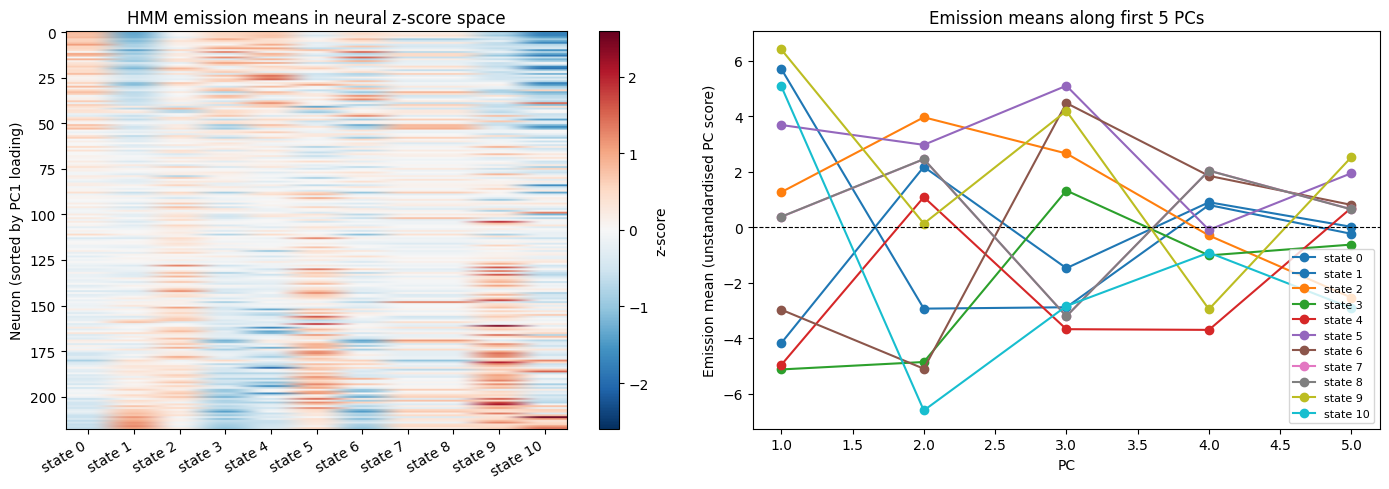

In [11]:
# =============================================================================
# SECTION 10 · Emission mean visualisation
# =============================================================================

means_orig   = hmm_final.means_
means_scaled = means_orig[new_order_keys]
means_pca_raw = scaler.inverse_transform(means_scaled)
means_neural  = pca_hmm.inverse_transform(means_pca_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neuron_order = np.argsort(pca_hmm.components_[0])
im0 = axes[0].imshow(means_neural[:, neuron_order].T,
                      aspect="auto", cmap="RdBu_r",
                      vmin=-np.abs(means_neural).max(),
                      vmax=np.abs(means_neural).max())
axes[0].set_xticks(range(K))
axes[0].set_xticklabels([f"state {s}" for s in range(K)],
                         rotation=30, ha="right")
axes[0].set_ylabel("Neuron (sorted by PC1 loading)")
axes[0].set_title("HMM emission means in neural z-score space")
plt.colorbar(im0, ax=axes[0], label="z-score")

n_show = min(5, N_PCS)
for s in range(K):
    axes[1].plot(range(1, n_show + 1), means_pca_raw[s, :n_show],
                 marker="o", label=f"state {s}", color=cmap_states(s / K))
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Emission mean (unstandardised PC score)")
axes[1].set_title(f"Emission means along first {n_show} PCs")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Most attack-enriched state in the selected model: 8  (attack fraction = 0.127)

Selected state 8 vs supervised attack conditions — Euclidean distances:


,WA,WN,DA,DN,HMM-s8
WA,0.0000,2.2940,5.5990,5.3430,3.2080
WN,2.2940,0.0000,5.3590,4.7590,2.8850
DA,5.5990,5.3590,0.0000,2.4080,7.0700
DN,5.3430,4.7590,2.4080,0.0000,6.6440
HMM-s8,3.2080,2.8850,7.0700,6.6440,0.0000



Cosine similarities:


,WA,WN,DA,DN,HMM-s8
WA,1.0000,0.8480,0.4260,0.3300,0.7780
WN,0.8480,1.0000,0.4600,0.4410,0.8240
DA,0.4260,0.4600,1.0000,0.9150,0.1710
DN,0.3300,0.4410,0.9150,1.0000,0.1140
HMM-s8,0.7780,0.8240,0.1710,0.1140,1.0000



Fraction of supervised bins assigned to state 8:
  WA: 25.9%  (481 / 1856 bins)
  WN: 21.9%  (2882 / 13144 bins)
  DA: 0.0%  (0 / 1175 bins)
  DN: 0.3%  (47 / 13825 bins)


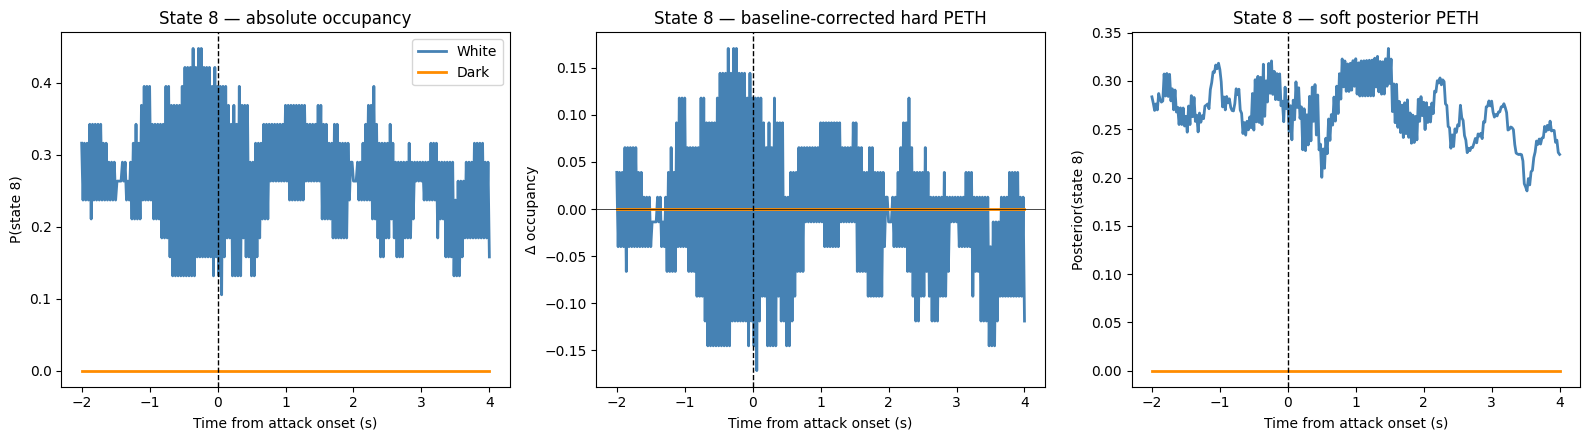

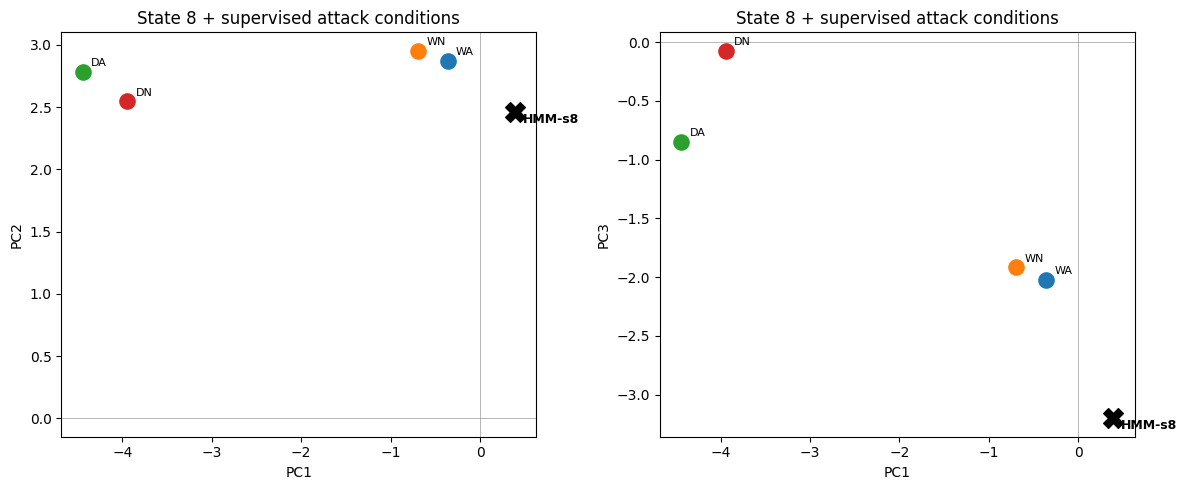

In [12]:
# =============================================================================
# OPTIONAL APPENDIX · SELECTED ATTACK-ENRICHED STATE DEEP-DIVE
# =============================================================================
# This is deliberately exploratory.
# It is useful for qualitative inspection, but it should not override the
# structure-first model choice above.

if "frac_in_state" in dir() and frac_in_state is not None and len(frac_in_state):
    attack_enrichment_by_state = frac_in_state["attack"]
    atk_state = int(attack_enrichment_by_state.idxmax())
    print(f"Most attack-enriched state in the selected model: {atk_state}  "
          f"(attack fraction = {attack_enrichment_by_state.max():.3f})")
else:
    atk_state = 0
    print(f"Using fallback atk_state = {atk_state}")

supervised_attack_masks = {
    "WA": phase_masks["WhiteAgg"] & attack,
    "WN": phase_masks["WhiteAgg"] & (~attack),
    "DA": phase_masks["DarkAgg"]  & attack,
    "DN": phase_masks["DarkAgg"]  & (~attack),
}

atk_state_centroid = condition_pattern(FRz, state_seq == atk_state)
sup_atk_centroids  = {nm: condition_pattern(FRz, m)
                      for nm, m in supervised_attack_masks.items()}
sup_atk_centroids[f"HMM-s{atk_state}"] = atk_state_centroid

eu_atk, cos_atk = pairwise_distance_tables(sup_atk_centroids)
print(f"\nSelected state {atk_state} vs supervised attack conditions — Euclidean distances:")
display(eu_atk.round(3))
print("\nCosine similarities:")
display(cos_atk.round(3))

print(f"\nFraction of supervised bins assigned to state {atk_state}:")
for nm, mask in supervised_attack_masks.items():
    in_s = (state_seq == atk_state) & mask
    pct  = 100 * in_s.sum() / max(mask.sum(), 1)
    print(f"  {nm}: {pct:.1f}%  ({in_s.sum()} / {mask.sum()} bins)")

hard_s_w_raw, soft_s_w_raw = raw_peth_single_state(
    state_seq, state_post, atk_state, white_onsets, pre_bins, post_bins)
hard_s_d_raw, soft_s_d_raw = raw_peth_single_state(
    state_seq, state_post, atk_state, dark_onsets,  pre_bins, post_bins)

bl_w = hard_s_w_raw[:pre_bins].mean()
bl_d = hard_s_d_raw[:pre_bins].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(time_event, hard_s_w_raw, lw=2, label="White", color="steelblue")
axes[0].plot(time_event, hard_s_d_raw, lw=2, label="Dark",  color="darkorange")
axes[0].axvline(0, color="k", lw=1, ls="--")
axes[0].set_xlabel("Time from attack onset (s)")
axes[0].set_ylabel(f"P(state {atk_state})")
axes[0].set_title(f"State {atk_state} — absolute occupancy")
axes[0].legend()

axes[1].plot(time_event, hard_s_w_raw - bl_w, lw=2, label="White", color="steelblue")
axes[1].plot(time_event, hard_s_d_raw - bl_d, lw=2, label="Dark",  color="darkorange")
axes[1].axvline(0, color="k", lw=1, ls="--")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("Time from attack onset (s)")
axes[1].set_ylabel("Δ occupancy")
axes[1].set_title(f"State {atk_state} — baseline-corrected hard PETH")

axes[2].plot(time_event, soft_s_w_raw, lw=2, label="White", color="steelblue")
axes[2].plot(time_event, soft_s_d_raw, lw=2, label="Dark",  color="darkorange")
axes[2].axvline(0, color="k", lw=1, ls="--")
axes[2].set_xlabel("Time from attack onset (s)")
axes[2].set_ylabel(f"Posterior(state {atk_state})")
axes[2].set_title(f"State {atk_state} — soft posterior PETH")

plt.tight_layout()
plt.show()

# Optional shared-PCA placement of this state
pca_shared_atk = PCA(n_components=3, random_state=0)
pca_shared_atk.fit(X_full)

X_atk_sup = np.stack([condition_pattern(FRz, v) for v in supervised_attack_masks.values()], axis=0)
Z_atk_sup = pca_shared_atk.transform(X_atk_sup)
Z_atk_hmm = pca_shared_atk.transform(atk_state_centroid[None, :])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_idx, (pc_x, pc_y) in enumerate([(0, 1), (0, 2)]):
    ax = axes[ax_idx]
    for i, nm in enumerate(supervised_attack_masks.keys()):
        ax.scatter(Z_atk_sup[i, pc_x], Z_atk_sup[i, pc_y],
                   s=120, marker="o", zorder=5, label=nm)
        ax.annotate(nm, (Z_atk_sup[i, pc_x], Z_atk_sup[i, pc_y]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.scatter(Z_atk_hmm[0, pc_x], Z_atk_hmm[0, pc_y],
               s=200, marker="X", color="black", zorder=6)
    ax.annotate(f"HMM-s{atk_state}", (Z_atk_hmm[0, pc_x], Z_atk_hmm[0, pc_y]),
                textcoords="offset points", xytext=(6, -8), fontsize=9, fontweight="bold")
    ax.axhline(0, lw=0.4, color="gray")
    ax.axvline(0, lw=0.4, color="gray")
    ax.set_xlabel(f"PC{pc_x+1}")
    ax.set_ylabel(f"PC{pc_y+1}")
    ax.set_title(f"State {atk_state} + supervised attack conditions")
plt.tight_layout()
plt.show()

Sweeping N_PCS × K (3 starts, 200 iter each)…
  N_PCS=10 done.
  N_PCS=15 done.
  N_PCS=20 done.
  N_PCS=30 done.


,N_PCS,K,n_params,logL,BIC,AIC,converged
0,10,3,68,-750011.7000,1500771.5000,1500159.4000,True
1,10,4,95,-699660.4000,1400366.1000,1399510.9000,True
2,10,5,124,-664721.9000,1330808.0000,1329691.7000,True
3,10,6,155,-667189.9000,1336085.1000,1334689.8000,True
4,10,7,188,-625935.6000,1253939.6000,1252247.2000,True
5,10,8,223,-622539.8000,1247533.0000,1245525.6000,True
6,15,3,98,-1172009.8000,2345097.9000,2344215.7000,True
7,15,4,135,-1122015.9000,2245517.1000,2244301.8000,True
8,15,5,174,-1086876.7000,2175667.8000,2174101.4000,True
9,15,6,215,-1084402.1000,2171169.7000,2169234.2000,True


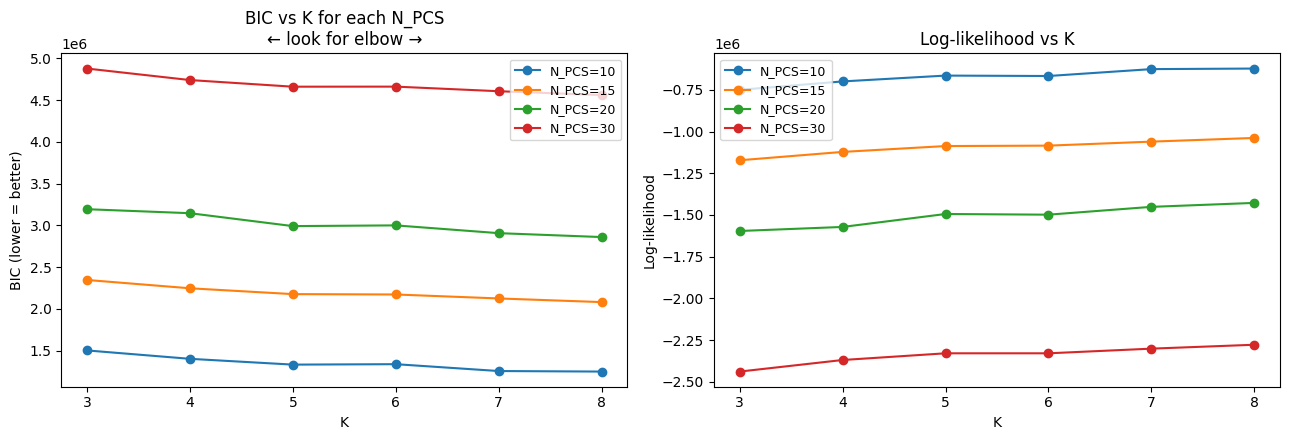


→ If BIC still falls monotonically for all N_PCS values,
  extend k_grid_quick to range(3, 13) and re-run.
  If an elbow appears, update N_PCS in Section 3 to that value.


In [13]:
# =============================================================================
# OPTIONAL APPENDIX · N_PCS sensitivity sweep
# =============================================================================

if not HMM_AVAILABLE:
    print("hmmlearn not available — skipping Cell A.")
else:
    pcs_to_test  = [10, 15, 20, 30]
    k_grid_quick = list(range(3, 9))

    npcs_sweep_rows = []
    print("Sweeping N_PCS × K (3 starts, 200 iter each)…")

    for n_pcs_try in pcs_to_test:
        pca_try   = PCA(n_components=n_pcs_try, random_state=0)
        X_raw_try = pca_try.fit_transform(X_full)
        X_try     = StandardScaler().fit_transform(X_raw_try)
        for k_try in k_grid_quick:
            m, ll = fit_hmm_multistart(X_try, n_states=k_try,
                                       n_starts=3, n_iter=200)
            bic, aic, n_par = hmm_bic_aic(ll, k_try, n_pcs_try, len(X_try))
            npcs_sweep_rows.append({
                "N_PCS": n_pcs_try, "K": k_try, "n_params": n_par,
                "logL": ll, "BIC": bic, "AIC": aic,
                "converged": m.monitor_.converged,
            })
        print(f"  N_PCS={n_pcs_try} done.")

    npcs_sweep_df = pd.DataFrame(npcs_sweep_rows)
    display(npcs_sweep_df.round(1))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for n_pcs_try in pcs_to_test:
        sub = npcs_sweep_df[npcs_sweep_df["N_PCS"] == n_pcs_try]
        axes[0].plot(sub["K"], sub["BIC"],  marker="o", label=f"N_PCS={n_pcs_try}")
        axes[1].plot(sub["K"], sub["logL"], marker="o", label=f"N_PCS={n_pcs_try}")

    axes[0].set_xlabel("K"); axes[0].set_ylabel("BIC (lower = better)")
    axes[0].set_title("BIC vs K for each N_PCS\n← look for elbow →")
    axes[0].legend(fontsize=9)
    axes[1].set_xlabel("K"); axes[1].set_ylabel("Log-likelihood")
    axes[1].set_title("Log-likelihood vs K")
    axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

    print("\n→ If BIC still falls monotonically for all N_PCS values,")
    print("  extend k_grid_quick to range(3, 13) and re-run.")
    print("  If an elbow appears, update N_PCS in Section 3 to that value.")



## 11. Compact summary tables

This section collects the main tables in one place so I can quickly reorient myself before an interview or discussion.


In [14]:
# =============================================================================
# COMPACT SUMMARY TABLES
# =============================================================================

print("=" * 72)
print("CANDIDATE MODEL TABLE")
display(ksel_df.round(4))

print("\n" + "=" * 72)
print("STRUCTURE-FIRST K COMPARISON")
display(compare_df.round(4))

print("\n" + "=" * 72)
print(f"SELECTED K = {K}  |  reason = {selection_reason}")
print(f"converged = {hmm_final.monitor_.converged}  |  train logL = {hmm_final.score(X_pca):.1f}")

print("\n" + "=" * 72)
print("STATE OCCUPANCY FRACTIONS")
display(occupancy.to_frame("fraction").T.round(3))

print("\n" + "=" * 72)
print("PHASE × STATE OCCUPANCY")
display(phase_occ_table.round(3))

print("\n" + "=" * 72)
print("PRE → POST OCCUPANCY CHANGE (bootstrap 95% CI)")
display(prepost_df.round(4))

print("\n" + "=" * 72)
print("BEHAVIOUR ENRICHMENT — HARD P(behaviour | state)")
display(frac_in_state.round(3))

print("\n" + "=" * 72)
print("BEHAVIOUR ENRICHMENT — SOFT P(state | behaviour)")
display(soft_pivot.round(3))

print("\n" + "=" * 72)
print("DWELL-TIME SUMMARY (s)")
display(dwell_summary.round(3))

print("\n" + "=" * 72)
print("NEAREST HMM STATE TO EACH SUPERVISED CONDITION")
display(sup_hmm_df.round(3))

CANDIDATE MODEL TABLE


,n_states,log_likelihood,n_params,BIC,BIC_corr,AIC,converged,cv_logL_per_bin,mean_ARI
0,8,-1427537.6524,383,2859289.1091,2856589.8997,2855841.3049,True,-28.2752,0.6764
1,9,-1409588.1322,440,2824017.1883,2820916.2688,2820056.2644,True,-28.1321,0.6092
2,10,-1396754.6719,499,2798999.3917,2795482.6672,2794507.3439,True,-27.6189,0.5968
3,11,-1401020.1765,560,2808201.5290,2804254.9042,2803160.3530,True,-27.9418,0.5203
4,12,-1367754.9474,623,2742364.2031,2737973.5831,2736755.8949,True,-27.4817,0.5511



STRUCTURE-FIRST K COMPARISON


,K,core_pass,phases_distinct,context_distinct,behaviours_distinct,phase_dominant,wa_nearest,da_nearest,beh_dominant,atk_state,atk_frac_in_state,white_attack_clean,dark_attack_clean,attack_purer_than_nonattack,attack_clean_pass,dist_WA,dist_WN,dist_DA,dist_DN,cos_WA,cos_WN,cos_DA,cos_DN,min_occ_frac,mean_dwell_s,median_dwell_s,log_likelihood,n_params,BIC,BIC_corr,AIC,cv_logL_per_bin,mean_ARI,converged
0,8,False,True,True,False,"{'Pre': 0, 'WhiteAgg': 3, 'DarkAgg': 1, 'Post'...",3,1,"{'attack': 3, 'submission': 3, 'sniff': 5}",3,0.1299,False,False,False,False,3.1747,2.8682,7.0749,6.6523,0.7830,0.8265,0.1701,0.1117,0.0719,1.9322,1.4650,-1427537.6524,383,2859289.1091,2856589.8997,2855841.3049,-28.2752,0.6764,True
1,9,False,True,True,False,"{'Pre': 0, 'WhiteAgg': 2, 'DarkAgg': 3, 'Post'...",2,4,"{'attack': 2, 'submission': 2, 'sniff': 5}",2,0.1300,False,False,False,False,3.1699,2.8438,7.0568,6.6346,0.7828,0.8289,0.1728,0.1143,0.0310,1.9978,1.2000,-1409588.1322,440,2824017.1883,2820916.2688,2820056.2644,-28.1321,0.6092,True
2,10,False,True,True,False,"{'Pre': 0, 'WhiteAgg': 1, 'DarkAgg': 2, 'Post'...",1,4,"{'attack': 1, 'submission': 1, 'sniff': 8}",4,0.1252,False,False,False,False,5.0027,4.8908,3.5788,3.0620,0.4955,0.5003,0.8027,0.8309,0.0307,1.6521,1.0400,-1396754.6719,499,2798999.3917,2795482.6672,2794507.3439,-27.6189,0.5968,True
3,11,True,True,True,True,"{'Pre': 1, 'WhiteAgg': 7, 'DarkAgg': 0, 'Post'...",7,0,"{'attack': 2, 'submission': 4, 'sniff': 5}",8,0.1274,False,False,False,False,3.2083,2.8850,7.0702,6.6440,0.7779,0.8239,0.1710,0.1135,0.0310,1.4448,0.7300,-1401020.1765,560,2808201.5290,2804254.9042,2803160.3530,-27.9418,0.5203,True
4,12,False,True,True,False,"{'Pre': 2, 'WhiteAgg': 0, 'DarkAgg': 1, 'Post'...",0,6,"{'attack': 0, 'submission': 0, 'sniff': 8}",6,0.1368,False,False,False,False,5.4856,5.3750,3.9329,3.6970,0.4668,0.4742,0.7791,0.7856,0.0306,1.4223,0.6450,-1367754.9474,623,2742364.2031,2737973.5831,2736755.8949,-27.4817,0.5511,True



SELECTED K = 11  |  reason = smallest K passing the core structure checks
converged = True  |  train logL = -1401020.2

STATE OCCUPANCY FRACTIONS


...

variable,attack,chase,lick_empty,lick_milk,sniff_urine,submission,white_light
state,,,,,,,
0,0.2050,0.0520,0.0000,0.0000,0.0000,0.1290,0.0770
1,0.0000,0.0000,0.0470,0.1440,0.1830,0.0000,0.0780
2,0.2070,0.3530,0.0240,0.0150,0.2580,0.1910,0.1530
3,0.0680,0.0000,0.0000,0.0000,0.0910,0.0000,0.0000
4,0.1650,0.1190,0.0000,0.0000,0.0000,0.2130,0.1720
5,0.0290,0.0000,0.2390,0.0010,0.2780,0.0380,0.0630
6,0.0720,0.0000,0.1160,0.0000,0.1770,0.0000,0.0000
7,0.1240,0.2150,0.0000,0.0000,0.0000,0.2050,0.2070
8,0.1250,0.2100,0.0000,0.0000,0.0000,0.2050,0.2070



DWELL-TIME SUMMARY (s)


,state,count,mean,median,std,sum
0,0,95,1.9450,1.7600,1.5350,184.7400
1,1,95,1.8730,1.2800,2.0110,177.9000
2,2,346,0.4490,0.3600,0.3040,155.5200
3,3,51,2.3280,2.0800,1.9030,118.7400
4,4,47,2.4170,1.5600,2.6030,113.6200
5,5,98,1.0690,0.5800,1.1170,104.8000
6,6,78,1.2480,0.7700,1.3070,97.3400
7,7,3779,0.0200,0.0200,0.0000,75.5800
8,8,3776,0.0200,0.0200,0.0000,75.5200
9,9,74,0.7970,0.2800,1.4620,58.9800



NEAREST HMM STATE TO EACH SUPERVISED CONDITION


,HMM-0,HMM-1,HMM-2,HMM-3,HMM-4,HMM-5,HMM-6,HMM-7,HMM-8,HMM-9,HMM-10,nearest_HMM_state
Pre_baseline,11.0810,1.2760,7.5390,11.7260,11.5060,5.3530,9.7480,7.1710,7.1690,1.8970,4.9720,HMM-1
Pre_sniff,13.2020,5.8490,8.0250,15.6690,14.0120,5.4540,13.8780,8.6660,8.6620,3.1410,9.3540,HMM-9
WA,3.8670,8.4020,1.9790,9.0670,4.9300,4.0520,8.3760,0.8530,0.8550,7.3180,10.9250,HMM-7
WN,3.5580,8.6990,2.2230,8.9680,4.6550,4.3810,8.3570,1.1850,1.1870,7.6550,11.1630,HMM-7
W_sub,2.9730,9.2500,2.7630,8.7750,4.1350,5.0160,8.3180,1.8170,1.8190,8.2880,11.5990,HMM-7
DA,0.6580,11.6520,5.8450,7.6610,1.7730,8.1310,8.0090,4.8350,4.8390,11.1840,13.3710,HMM-0
DN,0.4260,11.1010,5.4160,7.4860,1.7770,7.6430,7.6970,4.3260,4.3310,10.6430,12.8500,HMM-0
Post_sniff,4.8690,8.1660,7.3460,3.6570,4.2780,8.1270,2.7770,5.5830,5.5880,9.2020,8.6300,HMM-6
Post_baseline,6.8100,9.5480,9.9150,1.4520,5.8360,10.5830,0.8650,8.1520,8.1580,11.1670,8.9970,HMM-6


## 12. Bottom line

### What this notebook is good for
- validating whether the population scaffold survives **without labels**
- showing that I can reason about **model choice**, not just run a model
- exposing where the HMM agrees with the supervised story and where it does not

### What I should not overclaim
- a single clean context-invariant attack state
- a final mechanistic decomposition of aggression
- any cross-animal generalisation from this tiny example dataset

### How I would summarise it aloud
> I used the HMM as a label-free stress test of the supervised story.  
> The main thing I trust is the recovery of a phase-dominant latent scaffold and the occupancy-based remapping across the session.  
> The fine-grained attack interpretation is much less clean, and the notebook now makes that explicit instead of forcing a stronger claim.
